# RF Energy Harvester — **Complete** Notebook: design, sign-off and D05 tapeout

This is the single notebook that replaces both predecessors. It keeps everything from
`GLayout_RF_EnergyHarvester_Signoff.ipynb` — the IP-by-IP build, PEX extraction, post-layout
ngspice simulation, input-impedance and matching analysis, power/frequency sweeps and the
datasheet — and carries it all the way to a verified tapeout package for Chipathon 2026 slot
**D05**, with the defects the sign-off notebook missed repaired.

**Contents**

| Part | |
|---|---|
| 0–3 | environment, design dictionary, wiring library, sign-off wrappers |
| 4 | the nine IPs, each built → rendered → DRC'd → LVS'd |
| 5–7 | top assembly, D05 slot routing, dummy fill |
| 8 | physical sign-off on the exact shipped file |
| 9–13 | **PEX extraction, post-layout transient, parasitic audit, power/frequency sweeps, Zin + matching** |
| 14–16 | chip I/O and power, tapeout package, datasheet |

## What was wrong with the 19 Jul GDS

| # | Defect | Fix |
|---|---|---|
| 1 | **The MIM capacitors were metal shorts.** GLayout's gf180 `mimcap()` draws met2 + `CAP_MK` + a via2 array + met3. A real GF180 MIM needs **FuseTop (75/0)** as the top electrode (`mim_a.drc`: `mim7_l1 = fusetop.not(cap_mk)` — CAP_MK only *marks* FuseTop). No 75/0 existed, so every "capacitor" was a via stack and the 22 pF storage bank tied **VOUT to VSS**. | New IP `mimcap_b` (Part 4.6) |
| 2 | **Wrong metal pair.** `run_drc.py`'s variant table offers the met2/met3 MIM (`mim_option=A`) only for 3LM and 6LM. This is a **5LM** stack → only `mim_option=B`: **Metal4 / FuseTop / Via4 / Metal5**. | Caps rebuilt on met4/met5 |
| 3 | A bad bottom-plate stub welded each cap's plates together and left every bottom plate floating. | Superseded by the MIM-B rebuild |
| 4 | The GDS was one flat cell named `rf_energy_harvester$1`. | Hierarchical, `D05_`-prefixed, top cell `D05_Gelochip` |
| 5 | The five rail pads sat 137 µm inside the slot on met4 — **nothing reached the padring's Metal2 handover**. | Boundary router (Part 6) |
| 6 | Metal/poly density 0.1–11 % against a 30 %/14 % floor → **316** density violations. | Dummy fill (Part 7) |

## Why the old sign-off passed anyway

DRC was magic, whose `gf180mcuD` tech has no MIM device and a far thinner rule set; and LVS and
PEX both ran on the **FET view**, which contains no capacitors at all. Here DRC is the
**foundry KLayout deck** (`run_drc.py --variant=D`), and capacitors get a **plate-separation**
check, since no extractor available here models a MIM.

---
## Part 0 — Environment

The `.venv` the sign-off notebook used is gone. This runs in the `glayout_env` conda
environment with `PYTHONPATH` on this repo's `src/` — the other GLayout checkout on this
machine has an older `fet.py` without the `DUM` node and will fail. Both are baked into the
`glayout_env` kernelspec, so selecting that kernel is enough.

In [1]:
import os, sys, json, subprocess, shutil, inspect
from pathlib import Path

REPO    = Path("/home/irman/gLayout")
NBDIR   = REPO / "notebook"
TAPEOUT = NBDIR / "tapeout"
OUT     = NBDIR / "rf_harvester_tapeout_out"; OUT.mkdir(exist_ok=True)
IMG     = TAPEOUT / "img"; IMG.mkdir(exist_ok=True)
sys.path.insert(0, str(TAPEOUT))

os.environ.setdefault("PDK_ROOT",
    "/home/irman/pdks/volare/gf180mcu/versions/0fe599b2afb6708d281543108caf8310912f54af")
os.environ.setdefault("PDK", "gf180mcuD")
os.environ.setdefault("PDKPATH", os.environ["PDK_ROOT"] + "/gf180mcuD")
PDK_ROOT = os.environ["PDK_ROOT"]
VARIANT  = "EH"
TGZ      = NBDIR / "D05.def.tgz"

ENV      = {**os.environ, "PYTHONPATH": str(REPO/"src"), "PYTHONNOUSERSITE": "1",
            "D05_VARIANT": VARIANT}
ENV_NOPP = {**os.environ, "PYTHONPATH": "", "D05_VARIANT": VARIANT}

def run(script, env=None, tail=6000):
    r = subprocess.run([sys.executable, str(TAPEOUT/script)], capture_output=True,
                       text=True, env=env or ENV_NOPP, cwd=str(NBDIR))
    print((r.stdout or "")[-tail:] or (r.stderr or "")[-tail:])
    return r

import re, time
import klayout.db as kdb
from IPython.display import Image, display
from render import render
from klayout_view import klayout_png
from validate_ips import foundry_drc, netgen_lvs
from mim_verify import check as plate_check

def find_ngspice():
    # First ngspice >= 39 wins. gf180's BSIM4 cards need mulu0, which ngspice-36
    # does not have, so the system binary is unusable; the PandaChip IIC-OSIC-TOOLS
    # container carries ngspice-46. Returns (binary, PDK tree that binary can see).
    cands = []
    if os.environ.get("NGSPICE_BIN"):
        cands.append((os.environ["NGSPICE_BIN"], os.environ.get("SIM_PDKPATH", os.environ["PDKPATH"])))
    if os.path.exists("/home/irman/PandaChip/toolbin/ngspice"):
        cands.append(("/home/irman/PandaChip/toolbin/ngspice", "/foss/pdks/gf180mcuD"))
    cands.append(("ngspice", os.environ["PDKPATH"]))
    for b, pk in cands:
        try:
            o = subprocess.run([b, "--version"], capture_output=True, text=True, timeout=60).stdout
        except Exception:
            continue
        m = re.search(r"ngspice-(\d+)", o)
        if m and int(m.group(1)) >= 39:
            return b, pk, int(m.group(1))
    return None, None, None

NGSPICE_BIN, SIM_PDKPATH, _ngv = find_ngspice()
# the container only mounts /home/irman/PandaChip, so simulations must run there
SIMDIR = ("/home/irman/PandaChip/rfeh_sim"
          if NGSPICE_BIN and "PandaChip" in NGSPICE_BIN else str(OUT))
os.makedirs(SIMDIR, exist_ok=True)

print("python  :", sys.version.split()[0])
print("PDK_ROOT:", PDK_ROOT)
for t in ("magic", "netgen", "klayout"):
    print(f"{t:8s}:", shutil.which(t) or "NOT FOUND")
print("ngspice :", f"{NGSPICE_BIN} (v{_ngv}, PDK {SIM_PDKPATH})" if NGSPICE_BIN
      else "no ngspice >= 39 -- Parts 9-13 will skip")
print("sim dir :", SIMDIR)

python  : 3.10.20
PDK_ROOT: /home/irman/pdks/volare/gf180mcu/versions/0fe599b2afb6708d281543108caf8310912f54af
magic   : /home/irman/.nix-profile/bin/magic
netgen  : /home/irman/.nix-profile/bin/netgen
klayout : /home/irman/.nix-profile/bin/klayout
ngspice : /home/irman/PandaChip/toolbin/ngspice (v46, PDK /foss/pdks/gf180mcuD)
sim dir : /home/irman/PandaChip/rfeh_sim


---
## Part 1 — Imports and the design dictionary

The transistor IPs are loaded **verbatim** from the sign-off notebook: `ips.load()`
AST-filters its definition cells, keeping only imports, `def`s and `UPPER_CASE` constants. The
rectifier, bias, pump and load blocks below are therefore byte-identical to the ones that
already passed DRC and LVS — nothing was retyped. Only the capacitors are replaced.

In [2]:
from ips import load
g = load(OUT)
PDK, CONFIG = g["PDK"], g["CONFIG"]
evaluate_bbox = g["evaluate_bbox"]
print("Active PDK:", PDK.name, "\n")
print(json.dumps(CONFIG, indent=1))

Active PDK: gf180 

{
 "name": "rf_energy_harvester",
 "rectifier": {
  "pmos": {
   "width_um": 5.0,
   "length_um": 0.28
  },
  "nmos": {
   "width_um": 3.0,
   "length_um": 0.28
  }
 },
 "startup_bias": {
  "pmos": {
   "width_um": 4.0,
   "length_um": 1.0
  },
  "nmos": {
   "width_um": 2.0,
   "length_um": 1.0
  },
  "inject_cap_pf": 0.6
 },
 "charge_pump": {
  "diode": {
   "width_um": 4.0,
   "length_um": 0.28,
   "fingers": 2
  },
  "n_stages": 3,
  "stage_cap_pf": 1.2
 },
 "caps": {
  "storage_cap_pf": 20.0,
  "mim_ff_per_um2": 1.0,
  "stage_unit_um": [
   20.0,
   20.0
  ],
  "storage_unit_um": [
   28.0,
   28.0
  ]
 },
 "load": {
  "width_um": 1.0,
  "length_um": 10.0,
  "series_units": 8
 },
 "layout": {
  "gap_um": 8.0,
  "rail_width_um": 2.0,
  "lane_width_um": 0.8
 }
}


---
## Part 2 — Reusable wiring library

Carried over unchanged: `add_pin`, `ring_port`, `ring_anchor`, `mlink`, `lane_coord`,
`bridge_m3`. `mlink` is the workhorse — one straight bar on a chosen metal with a `via_stack`
landed on every member.

One override: `component_snap_to_grid` becomes the identity. Its own docstring says *"NOTE this
function will flatten the component"*, and calling it on the top is what produced the flat
`rf_energy_harvester$1` cell. The GDS writer already quantises to the 5 nm grid, so nothing is
lost by skipping it.

In [3]:
from ips import source_of
print(source_of(g, "mlink"))

def mlink(pdk, comp, items, lane, glayer="met3", width=0.8, ext=0.3, axis="v",
          via_size=None):
    """Connect rails/ring-elements with ONE straight bar of `glayer`:
    a via_stack lands on every member, then a single wide bar joins them.
    Bars on met3 may legally cross met2 rails and tie rings — this is how the
    opamp exits guarded cells. Members are port names (via placed where the
    rail crosses the lane) or {'x','y','glayer'} anchors (via placed exactly
    there, with a short stub over to the lane). axis='v': lane is x; 'h': y."""
    pts = []
    for it in items:
        if isinstance(it, str):
            p = comp.ports[it]
            pl = pdk.layer_to_glayer(p.layer)
            px, py = (float(v) for v in p.center)
            if axis == "v":
                x, y = lane, py
            else:
                x, y = px, lane
                if abs(py - lane) > 1e-6:   # stub on the port's own layer up/down to the rail
                    sw = min(width, float(

---
## Part 3 — Sign-off wrappers

* **`foundry_drc`** — the GF180 KLayout sign-off deck at `--variant=D` (5LM, `mim_option=B`),
  run on the written GDS and the exact cell name.
* **`netgen_lvs`** — netgen against the IP's own netlist, on a **flattened** copy. `add_pin`
  puts the pin rectangle and its label inside a sub-component, so on a hierarchical GDS the top
  cell owns no labels and netgen reports "no pins". The LVS design name must also be the
  netlist's own subckt name, and the source cell must be called something else — gdsfactory
  de-duplicates a repeated name to `NAME$1` and magic then loads an empty cell.
* **`plate_check`** — for capacitors: models `via4.interacting(fusetop)` as met5↔FuseTop and
  `via4.not_interacting(fusetop)` as met5↔met4, and **never** joins FuseTop to met4 — that gap
  *is* the capacitor. A naive "via4 joins met4 to met5" model calls a MIM a short, which is
  what hid defect 1.

In [4]:
print(inspect.getsource(foundry_drc))

def foundry_drc(gds, topcell, tag):
    rundir = Path(tempfile.mkdtemp(prefix=f"drc_{tag}_"))
    r = subprocess.run([sys.executable, str(DECK), f"--path={gds}", "--variant=D",
                        f"--topcell={topcell}", f"--run_dir={rundir}", "--mp=4"],
                       capture_output=True, text=True,
                       env={**os.environ, "PYTHONPATH": ""}, cwd=str(rundir))
    tot = collections.Counter()
    for f in glob.glob(str(rundir / "*.lyrdb")):
        try: root = ET.parse(f).getroot()
        except Exception: continue
        for it in root.iter("item"):
            c = (it.findtext("category") or "").strip("'\"")
            if c: tot[c] += 1
    clean = "DRC run is clean" in (r.stdout + r.stderr) and sum(tot.values()) == 0
    return clean, dict(tot)



---
## Part 4 — IP generators

Each block: **define → build → render → DRC → LVS**, one at a time.

### 4.1 Unit diode — guarded diode-connected NMOS

Dummies and body tie by construction; gate-drain strap with `c_route`, whose connector sits on met3 — remember that for anything routed *over* this cell. Nodes: P (=D=G), N (=S), B.

In [5]:
print(source_of(g, 'diode_nmos'))

def diode_nmos(pdk, width_um, length_um, fingers):
    """Diode-connected NMOS (dummies + body tie by construction). Nodes P(=D=G), N(=S), B."""
    fet = nmos(pdk, width=width_um, length=length_um, fingers=fingers,
               with_tie=True, with_dummy=True, with_dnwell=False,
               with_substrate_tap=False)
    d = Component()
    ref = d << fet
    d.add_ports(ref.get_ports_list())
    d << c_route(pdk, ref.ports["multiplier_0_gate_E"], ref.ports["multiplier_0_drain_E"])
    nl = Netlist(circuit_name="NDIODE", nodes=["P", "N", "B"])
    nl.connect_netlist(fet.info["netlist"],
                       [("D", "P"), ("G", "P"), ("S", "N"), ("B", "B"), ("DUM", "B")])
    d.info["netlist"] = nl
    d = component_snap_to_grid(rename_ports_by_orientation(d))
    d.info["netlist"] = nl
    return d


unit_diode: 10.78 x 9.09 um, 1776 ports


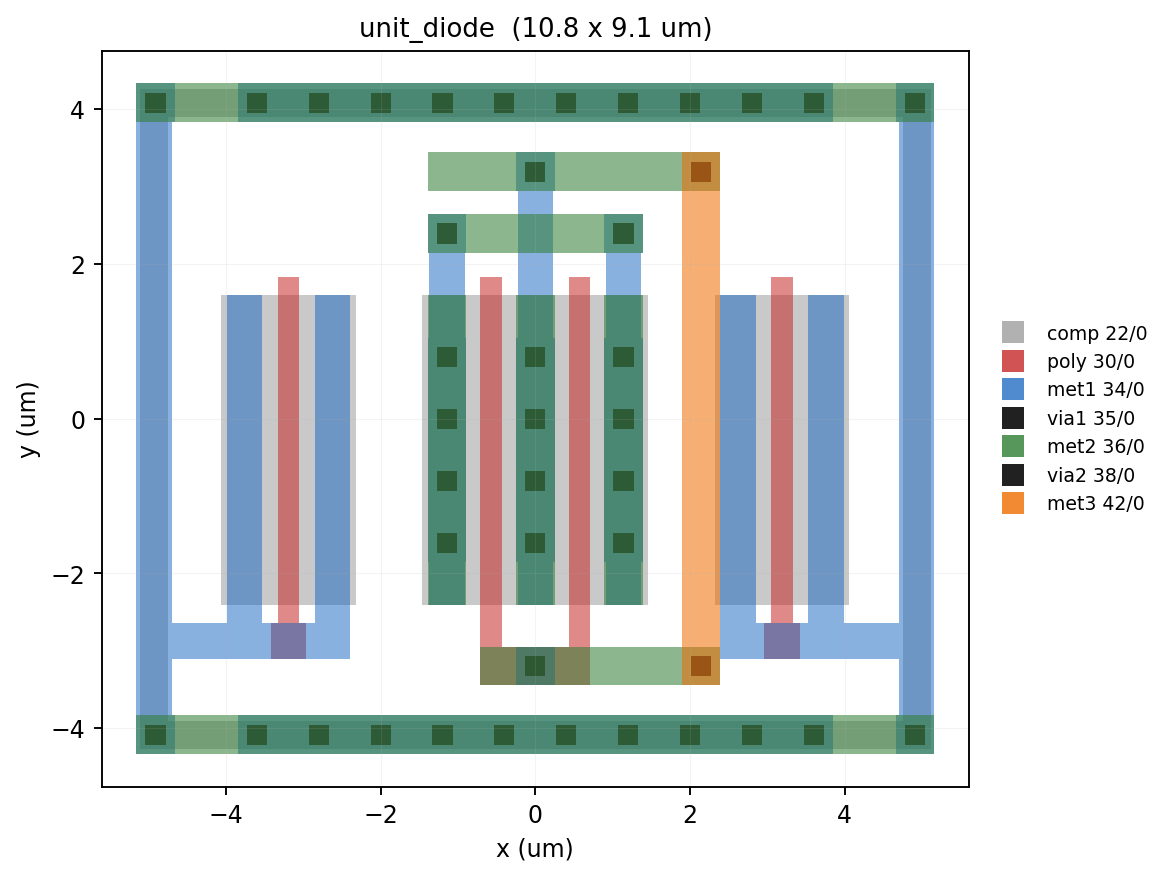

In [6]:
unit_diode = g['diode_nmos'](PDK, 4.0, 0.28, 2)
unit_diode.name = "unit_diode"
w, h = evaluate_bbox(unit_diode)
print(f"unit_diode: {w:.2f} x {h:.2f} um, {len(unit_diode.ports)} ports")
gds = OUT / "ip_unit_diode.gds"; unit_diode.write_gds(str(gds))
render(gds, IMG / "ip_unit_diode.png", "unit_diode  ({:.1f} x {:.1f} um)".format(w, h), figsize=(7,7))
display(Image(filename=str(IMG / "ip_unit_diode.png")))

In [7]:
ok, items = foundry_drc(OUT / "ip_unit_diode.gds", "unit_diode", "unit_diode")
print("DRC (foundry deck, variant D):", "CLEAN" if ok else items)
print("LVS (netgen):", "MATCH" if netgen_lvs(unit_diode, "unit_diode", PDK, PDK_ROOT) else "MISMATCH")

DRC (foundry deck, variant D): CLEAN
LVS (netgen): MATCH


### 4.2 Cross-coupled rectifier

Cross-coupled PMOS and NMOS pairs: each RF phase drives the devices that conduct on the opposite phase, giving synchronous full-wave rectification with less forward loss than a diode chain. One met3 lane per net lands a `via_stack` on every rail it owns — that single bar *is* the cross-coupling.

In [8]:
print(source_of(g, 'rectifier'))

def rectifier(pdk, cfg):
    """Differential cross-coupled rectifier (PMOS pair over NMOS pair).

    Wiring is four met3 lanes (columns), each one net:
      VRECT = P drains + nwell ring    RFP = P.A_src + P.B_gate + N.A_src + N.B_gate
      VSS   = N drains + psub ring     RFN = P.B_src + P.A_gate + N.B_src + N.A_gate
    The RFP/RFN lanes ARE the cross-coupling — one bar connects source rails and
    the opposite device's gate rail in both pairs."""
    rp, rn = cfg["rectifier"]["pmos"], cfg["rectifier"]["nmos"]
    gap, lw = cfg["layout"]["gap_um"], cfg["layout"]["lane_width_um"]
    comp = Component()
    pp = two_pfet_interdigitized(pdk, numcols=2, width=rp["width_um"],
                                 length=rp["length_um"], dummy=True,
                                 with_substrate_tap=False, with_tie=True)
    nn = two_nfet_interdigitized(pdk, numcols=2, width=rn["width_um"],
                                 length=rn["length_um"], dummy=True,
                               

rectifier: 17.23 x 32.87 um, 5888 ports


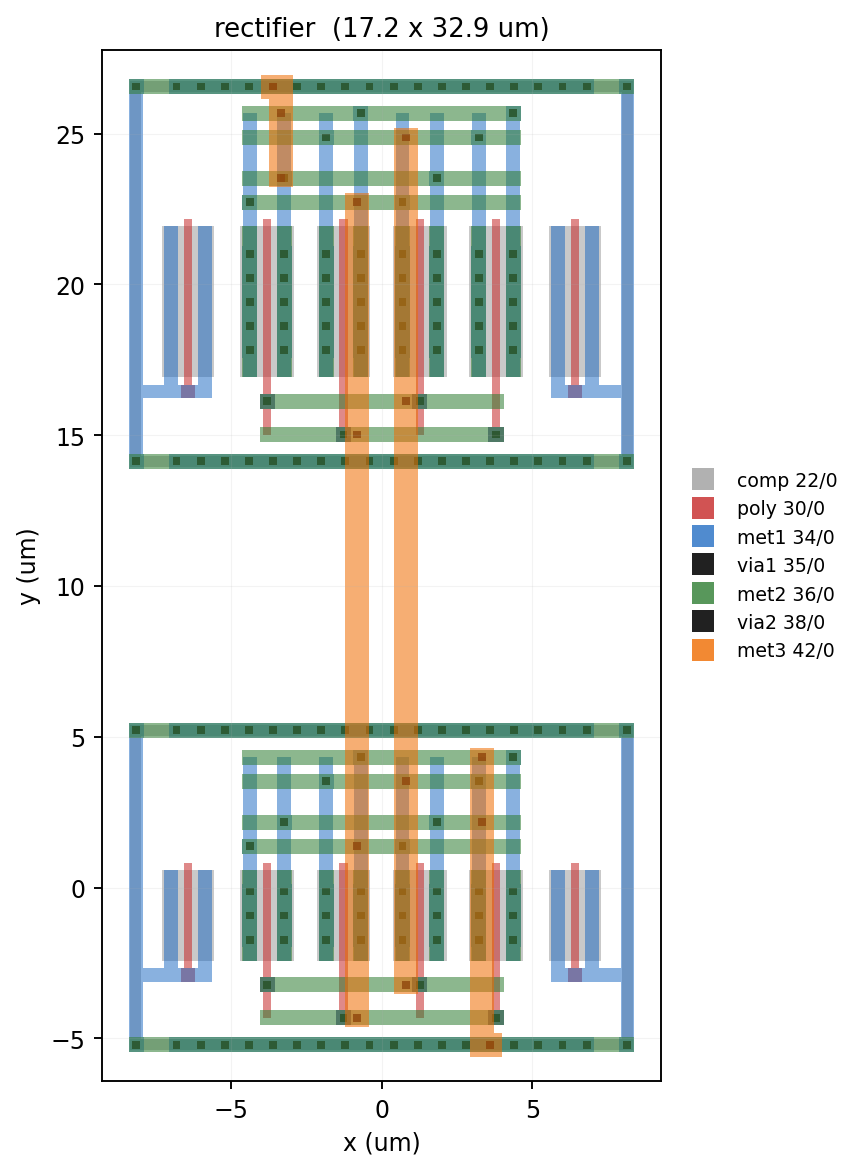

In [9]:
rectifier = g['rectifier'](PDK, CONFIG)
rectifier.name = "rectifier"
w, h = evaluate_bbox(rectifier)
print(f"rectifier: {w:.2f} x {h:.2f} um, {len(rectifier.ports)} ports")
gds = OUT / "ip_rectifier.gds"; rectifier.write_gds(str(gds))
render(gds, IMG / "ip_rectifier.png", "rectifier  ({:.1f} x {:.1f} um)".format(w, h), figsize=(7,7))
display(Image(filename=str(IMG / "ip_rectifier.png")))

In [10]:
ok, items = foundry_drc(OUT / "ip_rectifier.gds", "rectifier", "rectifier")
print("DRC (foundry deck, variant D):", "CLEAN" if ok else items)
print("LVS (netgen):", "MATCH" if netgen_lvs(rectifier, "rectifier", PDK, PDK_ROOT) else "MISMATCH")

DRC (foundry deck, variant D): CLEAN
LVS (netgen): MATCH


### 4.3 Injection-assisted startup bias

Two-leg bias that injects charge into the rectifier mid-nodes so the pump starts from a cold rail. Exposes VMID1 / VMID2, which the inject capacitors drive.

In [11]:
print(source_of(g, 'startup_bias'))

def startup_bias(pdk, cfg):
    """Two diode-divider legs: VRECT -PMOS diode- VMIDx -NMOS diode- VSS.
    Lane per net again; the VMID lanes implement the gate-drain diode straps of
    all four devices. Top-level inject caps couple RFP->VMID1 / RFN->VMID2."""
    sp, sn = cfg["startup_bias"]["pmos"], cfg["startup_bias"]["nmos"]
    gap, lw = cfg["layout"]["gap_um"], cfg["layout"]["lane_width_um"]
    comp = Component()
    pp = two_pfet_interdigitized(pdk, numcols=2, width=sp["width_um"],
                                 length=sp["length_um"], dummy=True,
                                 with_substrate_tap=False, with_tie=True)
    nn = two_nfet_interdigitized(pdk, numcols=2, width=sn["width_um"],
                                 length=sn["length_um"], dummy=True,
                                 with_substrate_tap=False, with_tie=True)
    _stack_pairs(pdk, comp, pp, nn, gap)

    nets = {
        "VRECT": (["P_A_source_W", "P_B_source_W"], 0.14),
        "VMID1": (["P_A_drain_W", 

startup_bias: 19.75 x 30.87 um, 5184 ports


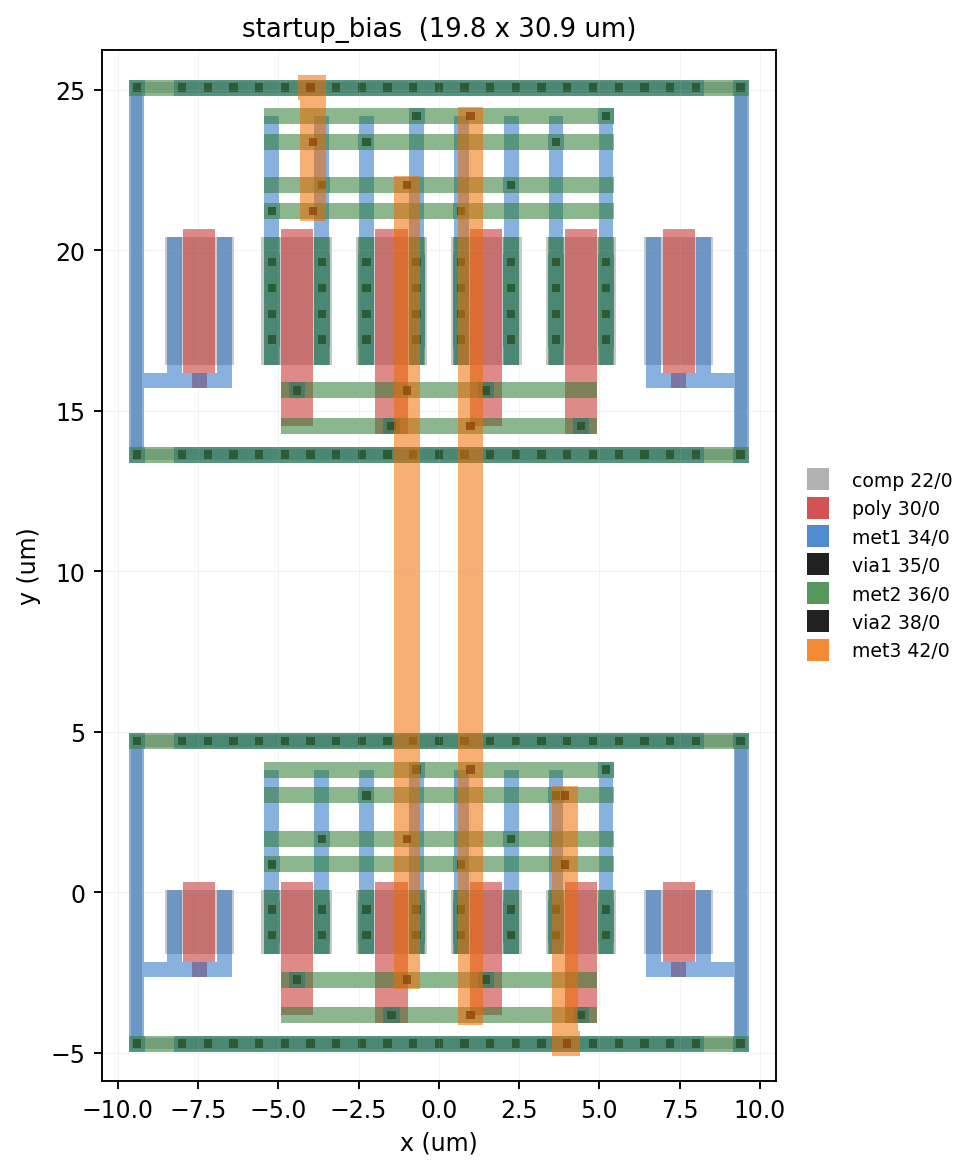

In [12]:
startup_bias = g['startup_bias'](PDK, CONFIG)
startup_bias.name = "startup_bias"
w, h = evaluate_bbox(startup_bias)
print(f"startup_bias: {w:.2f} x {h:.2f} um, {len(startup_bias.ports)} ports")
gds = OUT / "ip_startup_bias.gds"; startup_bias.write_gds(str(gds))
render(gds, IMG / "ip_startup_bias.png", "startup_bias  ({:.1f} x {:.1f} um)".format(w, h), figsize=(7,7))
display(Image(filename=str(IMG / "ip_startup_bias.png")))

In [13]:
ok, items = foundry_drc(OUT / "ip_startup_bias.gds", "startup_bias", "startup_bias")
print("DRC (foundry deck, variant D):", "CLEAN" if ok else items)
print("LVS (netgen):", "MATCH" if netgen_lvs(startup_bias, "startup_bias", PDK, PDK_ROOT) else "MISMATCH")

DRC (foundry deck, variant D): CLEAN
LVS (netgen): MATCH


### 4.4 Dickson charge-pump ladder (3 stages)

Three diode-connected NMOS stages transfer charge forward while the stage capacitors receive alternating excitation from the differential RF phases. N1 and N2 are the inter-stage nodes.

In [14]:
print(source_of(g, 'pump_ladder'))

def pump_ladder(pdk, cfg):
    """Dickson ladder: VRECT -D0- N1 -D1- N2 -D2- VOUT (anode = D=G, cathode = S).
    Identical guarded unit diodes; bodies/dummies on VSS tie rings joined by a
    met3 rail below the row (via_stack drop per ring)."""
    cp = cfg["charge_pump"]
    n = cp["n_stages"]
    gap, lw = cfg["layout"]["gap_um"], cfg["layout"]["lane_width_um"]
    comp = Component()
    dio = diode_nmos(pdk, cp["diode"]["width_um"], cp["diode"]["length_um"],
                     cp["diode"]["fingers"])
    dw, dh = evaluate_bbox(dio)
    pitch = dw + gap
    for i in range(n):
        rd = comp << dio
        prec_ref_center(rd)
        rd.movex(i * pitch)
        comp.add_ports(rd.get_ports_list(), prefix=f"D{i}_")
    # chain: cathode(i) [source, E] -> anode(i+1) [drain, W] on a met3 bridge
    # (the rails sit at different heights; met2 detours would short the next
    #  diode's rails, a met3 bar with a via on each rail end crosses cleanly)
    for i in range(n - 1):
        b

pump_ladder: 48.34 x 14.09 um, 5333 ports


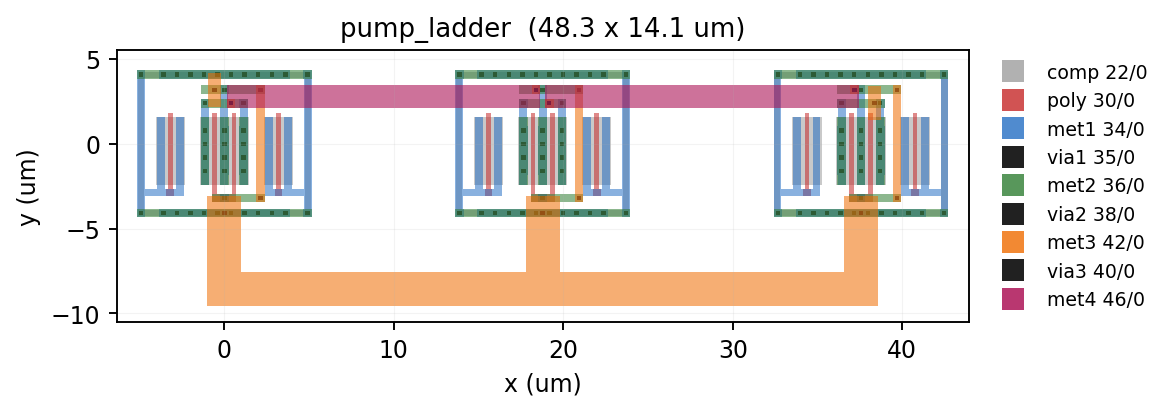

In [15]:
pump_ladder = g['pump_ladder'](PDK, CONFIG)
pump_ladder.name = "pump_ladder"
w, h = evaluate_bbox(pump_ladder)
print(f"pump_ladder: {w:.2f} x {h:.2f} um, {len(pump_ladder.ports)} ports")
gds = OUT / "ip_pump_ladder.gds"; pump_ladder.write_gds(str(gds))
render(gds, IMG / "ip_pump_ladder.png", "pump_ladder  ({:.1f} x {:.1f} um)".format(w, h), figsize=(7,7))
display(Image(filename=str(IMG / "ip_pump_ladder.png")))

In [16]:
ok, items = foundry_drc(OUT / "ip_pump_ladder.gds", "pump_ladder", "pump_ladder")
print("DRC (foundry deck, variant D):", "CLEAN" if ok else items)
print("LVS (netgen):", "MATCH" if netgen_lvs(pump_ladder, "pump_ladder", PDK, PDK_ROOT) else "MISMATCH")

DRC (foundry deck, variant D): CLEAN
LVS (netgen): MATCH


### 4.5 Output load — diode-connected long-channel NMOS

Eight series long-channel units set the DC load at VOUT.

In [17]:
print(source_of(g, 'load_diode'))

def load_diode(pdk, cfg):
    """Output load: a long-channel diode-connected NMOS between VOUT and VSS.
    (glayout's `resistor` PCell was tried first, but in this version its layout
    wires the series units in parallel/shorted — its netlist disagrees with its
    own geometry, so it cannot pass LVS. A MOS diode load is the standard
    integrated alternative and reuses the verified NDIODE cell.)"""
    ld = cfg["load"]
    comp = Component()
    dio = diode_nmos(pdk, ld["width_um"], ld["length_um"], 1)
    rd = comp << dio
    prec_ref_center(rd)
    comp.add_ports(rd.get_ports_list())
    # VSS: source rail strapped over the gate rail onto the psub tie ring (met3)
    sx = (float(comp.ports["source_W"].center[0]) + float(comp.ports["source_E"].center[0])) / 2
    mlink(pdk, comp, ["source_W", ring_anchor(pdk, comp, "tie", "S", near_x=sx)],
          sx, width=cfg["layout"]["lane_width_um"])
    dx = (float(comp.ports["drain_W"].center[0]) + float(comp.ports["drain_E"].center[0])) 

load_diode: 37.91 x 6.10 um, 1978 ports


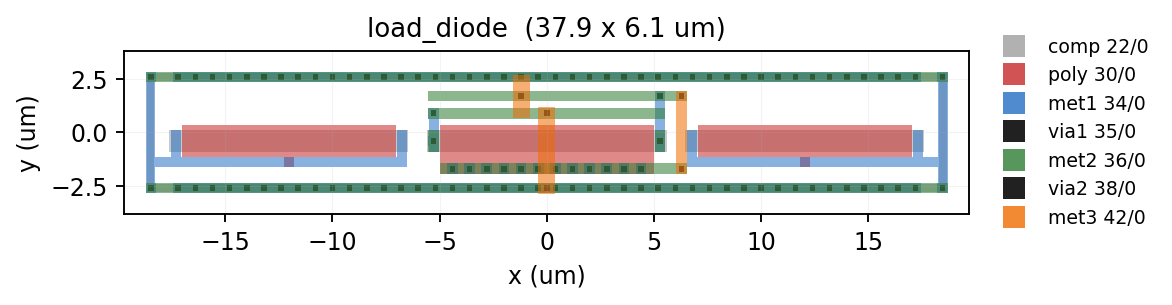

In [18]:
load_diode = g['load_diode'](PDK, CONFIG)
load_diode.name = "load_diode"
w, h = evaluate_bbox(load_diode)
print(f"load_diode: {w:.2f} x {h:.2f} um, {len(load_diode.ports)} ports")
gds = OUT / "ip_load_diode.gds"; load_diode.write_gds(str(gds))
render(gds, IMG / "ip_load_diode.png", "load_diode  ({:.1f} x {:.1f} um)".format(w, h), figsize=(7,7))
display(Image(filename=str(IMG / "ip_load_diode.png")))

In [19]:
ok, items = foundry_drc(OUT / "ip_load_diode.gds", "load_diode", "load_diode")
print("DRC (foundry deck, variant D):", "CLEAN" if ok else items)
print("LVS (netgen):", "MATCH" if netgen_lvs(load_diode, "load_diode", PDK, PDK_ROOT) else "MISMATCH")

DRC (foundry deck, variant D): CLEAN
LVS (netgen): MATCH


### 4.6 MIM-B capacitor — the new IP

The block that did not exist before. A real GF180 MIM needs **FuseTop (75/0)** as the top
electrode, and the metal pair depends on the stack. `run_drc.py`'s variant table is
authoritative:

| variant | metal_top | mim_option | metal_level |
|---|---|---|---|
| A | 30K | A | 3LM |
| B | 11K | B | 4LM |
| C | 9K | **B** | **5LM** |
| D | 11K | **B** | **5LM** |
| E | 9K | B | 6LM |
| F | 9K | A | 6LM |

This design is 5LM — met1…met5, and the padring's `gf180mcu_fd_io__asig_5p0` is a 5LM cell — so
**only `mim_option=B` exists**: bottom plate **Metal4**, top plate **FuseTop**, contact
**Via4**, and *both* terminals on **Metal5**, because MIMTM.10 forbids contacting the Metal4
bottom plate from below.

| Rule | Constraint | Used |
|---|---|---|
| MIMTM.1 | met4 to a neighbouring MIM bottom plate ≥ 1.2 µm | 1.4 |
| MIMTM.2 | met4 encloses via4 inside the MIM region ≥ 0.4 | 0.5 |
| MIMTM.3 | met4 encloses FuseTop ≥ 0.6 | 0.8 |
| MIMTM.4 | FuseTop encloses via4 ≥ 0.4 | 0.4 |
| MIMTM.5 | FuseTop to the bottom-contact via4 ≥ 0.4 | 0.5 |
| MIMTM.6 | FuseTop to unrelated FuseTop ≥ 0.6 | 1.4 |
| MIMTM.7 | FuseTop covered by CAP_MK ≥ 0 | 0.2 |
| MIMTM.8a/8b | FuseTop area 25 … 10000 µm² | enforced |
| MIMTM.9 | via4 spacing on the top plate ≥ 0.5 | 0.54 |
| MIMTM.10 | no Via3 may touch the Metal4 bottom plate | both terminals on met5 |
| MIMTM.11 | total FuseTop per shared bottom plate ≤ 10000 µm² | one plate per unit |

In [20]:
from mimcap_b import mimcap_b, mimcap_b_array
print(inspect.getsource(mimcap_b))

def mimcap_b(pdk, size=(28.0, 28.0), ff_per_um2=1.0, name=None):
    """One MIM-B unit, centred on its FuseTop plate.

    Ports: TOP_N (met5, top plate) and BOT_S (met5, bottom plate), both on met5
    because MIMTM.10 forbids contacting the Metal4 bottom plate from below.
    """
    W, H = size
    area = W * H
    if area < 25.0:
        raise ValueError(f"MIMTM.8a: FuseTop area {area:.1f} um^2 < 25 um^2")
    if area > 10000.0:
        raise ValueError(f"MIMTM.8b: FuseTop area {area:.1f} um^2 > 10000 um^2")

    c = Component(name=name or f"mimcap_b_{W:g}x{H:g}")
    m4, m5 = pdk.get_glayer("met4"), pdk.get_glayer("met5")
    v4 = pdk.get_glayer("via4")
    hw, hh = W / 2.0, H / 2.0

    # ---- top plate: FuseTop + its CAP_MK marker --------------------------
    _rect(c, -hw, -hh, hw, hh, FUSETOP)
    _rect(c, -hw - CAPMK_ENC, -hh - CAPMK_ENC, hw + CAPMK_ENC, hh + CAPMK_ENC, CAPMK)

    # ---- bottom plate: Metal4, enclosing FuseTop, extended south for the
    #      bottom conta

MIM-B unit: 29.60 x 30.06 um -> 0.784 pF (FuseTop 784 um^2, 1156 top vias, 36 bottom vias)


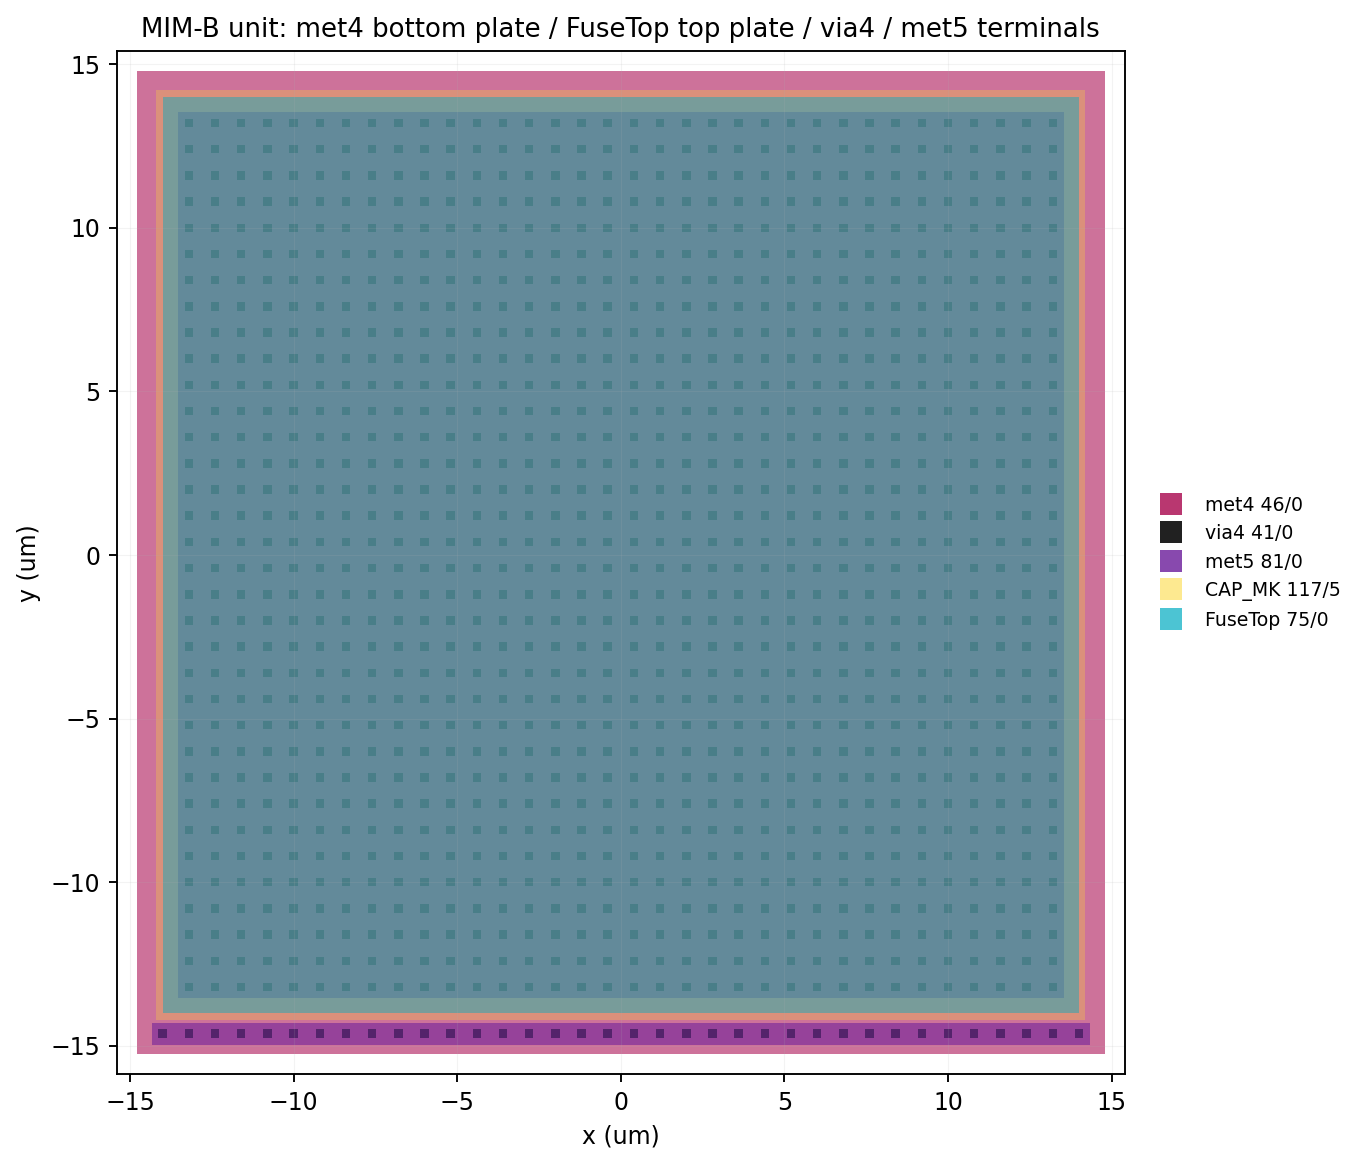

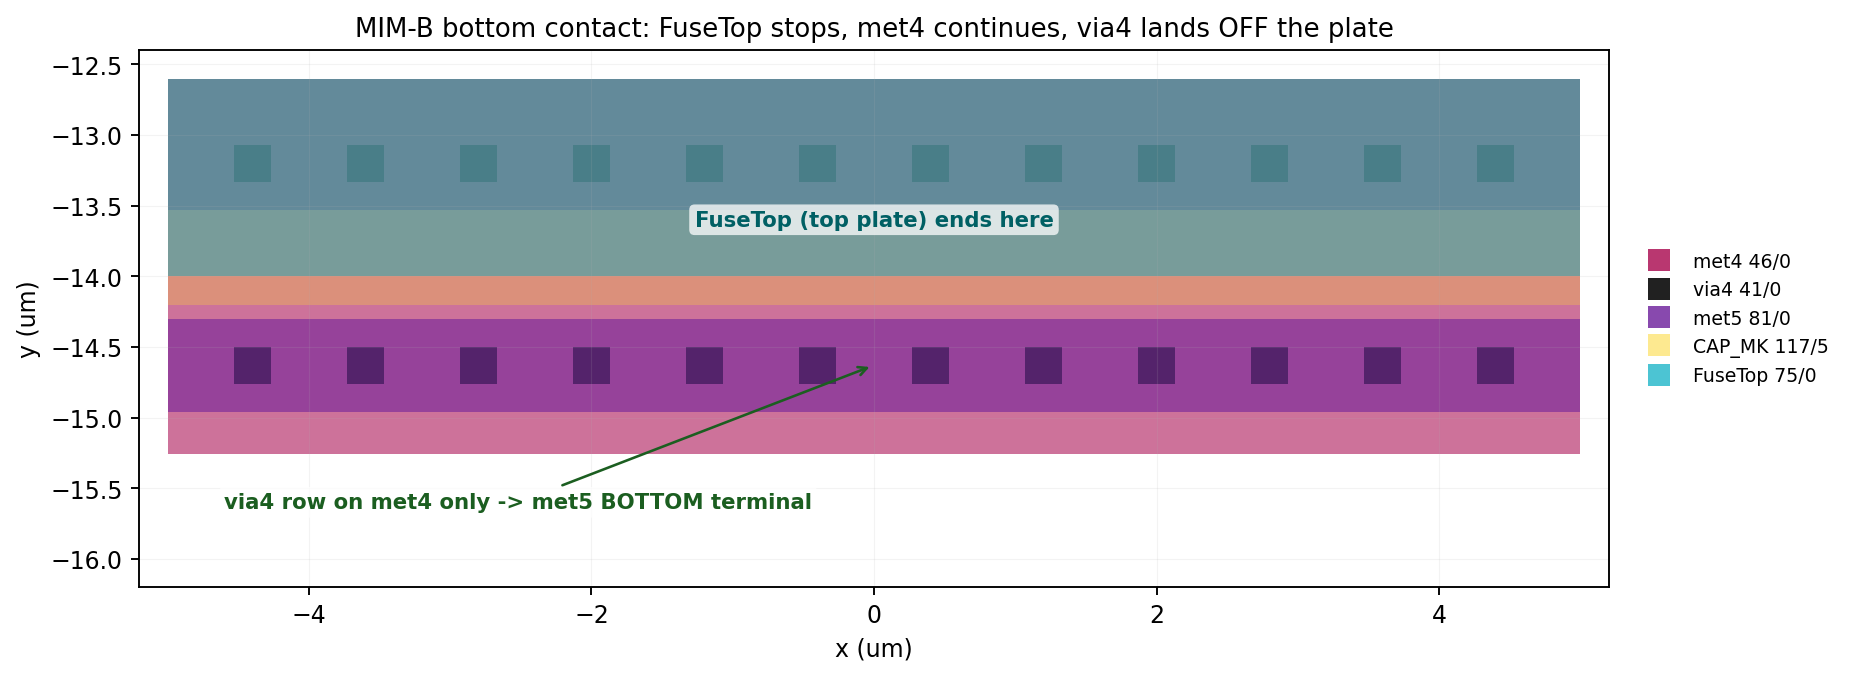

In [21]:
mimb = mimcap_b(PDK, (28.0, 28.0)); mimb.name = "mimb_unit"
w, h = evaluate_bbox(mimb)
print(f"MIM-B unit: {w:.2f} x {h:.2f} um -> {mimb.info['capacitance_pf']:.3f} pF "
      f"(FuseTop {mimb.info['fusetop_area_um2']:.0f} um^2, "
      f"{mimb.info['n_top_vias']} top vias, {mimb.info['n_bot_vias']} bottom vias)")
gds = OUT / "ip_mimb_unit.gds"; mimb.write_gds(str(gds))
render(gds, IMG / "ip_mimb_unit.png",
       "MIM-B unit: met4 bottom plate / FuseTop top plate / via4 / met5 terminals", figsize=(8,8))
display(Image(filename=str(IMG / "ip_mimb_unit.png")))
display(Image(filename=str(IMG / "11_mimb_corner.png")))

The same cell rendered a second time by **KLayout's own engine** with the foundry layer
properties (`gf180mcu.lyp`). `render.py` is our matplotlib code interpreting parsed polygons;
this is KLayout reading the GDS itself. Two independent paths — if they agree, the geometry is
what we think it is.

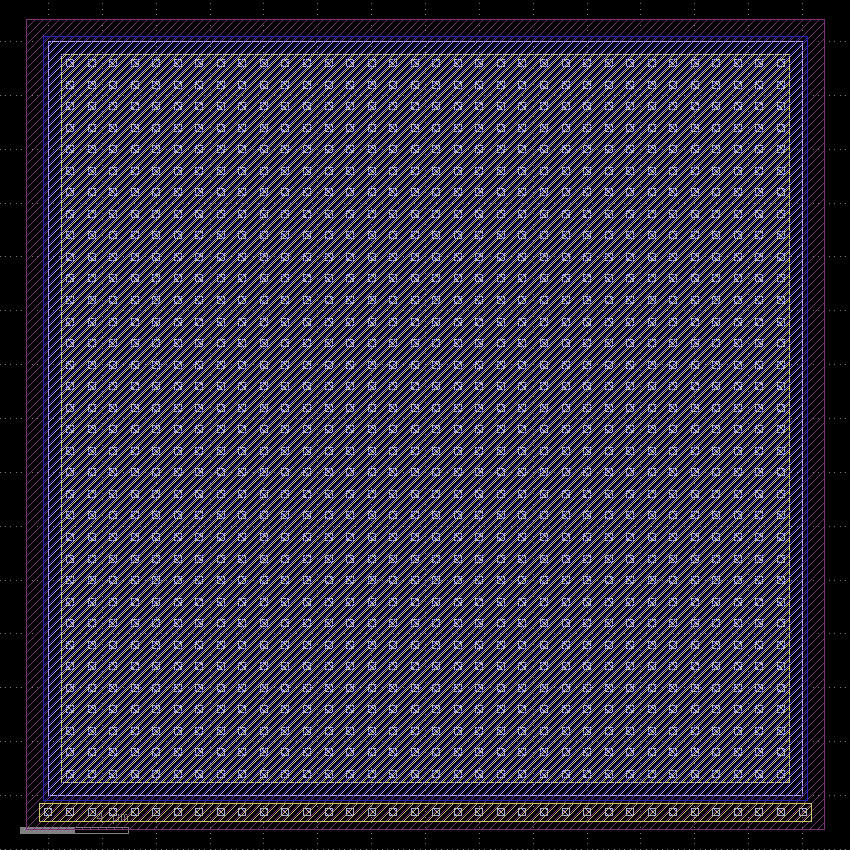

In [22]:
klayout_png(OUT / "ip_mimb_unit.gds", IMG / "ip_mimb_unit_klayout.png", width=850, height=850)
display(Image(filename=str(IMG / "ip_mimb_unit_klayout.png")))

In [23]:
ok, items = foundry_drc(OUT / "ip_mimb_unit.gds", "mimb_unit", "mimb_unit")
print("DRC (foundry deck, variant D):", "CLEAN" if ok else items, "\n")
nets = plate_check(OUT / "ip_mimb_unit.gds",
                   {"TOP plate (fusetop)": ("fusetop", 0.0, 0.0),
                    "TOP terminal (met5)": ("met5", 0.0, 0.0),
                    "BOT plate (met4)":    ("met4", 0.0, 14.4),
                    "BOT terminal (met5)": ("met5", 0.0, -14.63)})
print("\ntop plate reaches its terminal   :", nets["TOP plate (fusetop)"] == nets["TOP terminal (met5)"])
print("bottom plate reaches its terminal :", nets["BOT plate (met4)"] == nets["BOT terminal (met5)"])
print("the plates are SEPARATE nets      :", nets["TOP terminal (met5)"] != nets["BOT terminal (met5)"],
      "  <-- this is what makes it a capacitor")

DRC (foundry deck, variant D): CLEAN 

  FuseTop    1 plate(s),     784.0 um^2  -> 0.784 pF at 1.0 fF/um^2
  CAP_MK     1 marker(s)   via4 total  1192  (1156 on FuseTop, 36 ordinary)
  probe TOP plate (fusetop) fusetop  (    0.00,    0.00) -> net 2
  probe TOP terminal (met5) met5     (    0.00,    0.00) -> net 2
  probe BOT plate (met4) met4     (    0.00,   14.40) -> net 1
  probe BOT terminal (met5) met5     (    0.00,  -14.63) -> net 1

top plate reaches its terminal   : True
bottom plate reaches its terminal : True
the plates are SEPARATE nets      : True   <-- this is what makes it a capacitor


Read the DRC log, not just the verdict: it must say **`MIM Option selected: B`** and
**`fusetop has N polygons`**. Without FuseTop the MIM rules match nothing and pass *vacuously*
— precisely why the old layout was "DRC clean" while being a short.

### 4.7 Capacitor banks

`ips.make_cap_blocks()` replaces the notebook's `cap_block` / `cap_block_storage` with MIM-B
arrays exposing the same `TOP_stub_N` / `BOT_stub_S` port names — but on **met5**. Unit size is
chosen per bank so the target value is hit almost exactly, subject to MIMTM.8b's 10000 µm²
per-cap ceiling. The old banks quantised to 0.40 / 1.20 / 21.95 pF; these hit
0.300 / 1.200 / 19.998 pF.

In [24]:
banks = {}
banks["inject"]  = g["cap_block"](PDK, CONFIG, CONFIG["startup_bias"]["inject_cap_pf"]/2, max_cols=1)
banks["stage"]   = g["cap_block"](PDK, CONFIG, CONFIG["charge_pump"]["stage_cap_pf"], max_cols=1)
banks["storage"] = g["cap_block_storage"](PDK, CONFIG)
for nm, b in banks.items():
    b.name = f"cap_{nm}"
    w, h = evaluate_bbox(b)
    gds = OUT / f"ip_cap_{nm}.gds"; b.write_gds(str(gds))
    render(gds, IMG / f"ip_cap_{nm}.png",
           f"cap_{nm}: {b.info['capacitance_pf']:.3f} pF  ({w:.1f} x {h:.1f} um)", figsize=(6,6))
    print(f"{nm:8s} {b.info['capacitance_pf']:7.3f} pF   {w:7.1f} x {h:6.1f} um")

[mimcap_b] 0.3 pF -> 1x1 of 17.320 um square = 0.300 pF  (25.7 x 19.4 um)
[mimcap_b] 1.2 pF -> 2x1 of 24.495 um square = 1.200 pF  (32.9 x 54.5 um)
[mimcap_b] 20.0 pF -> 4x7 of 26.725 um square = 19.998 pF  (213.5 x 119.4 um)
inject     0.300 pF      25.7 x   19.4 um


stage      1.200 pF      32.9 x   54.5 um


storage   19.998 pF     213.5 x  119.4 um


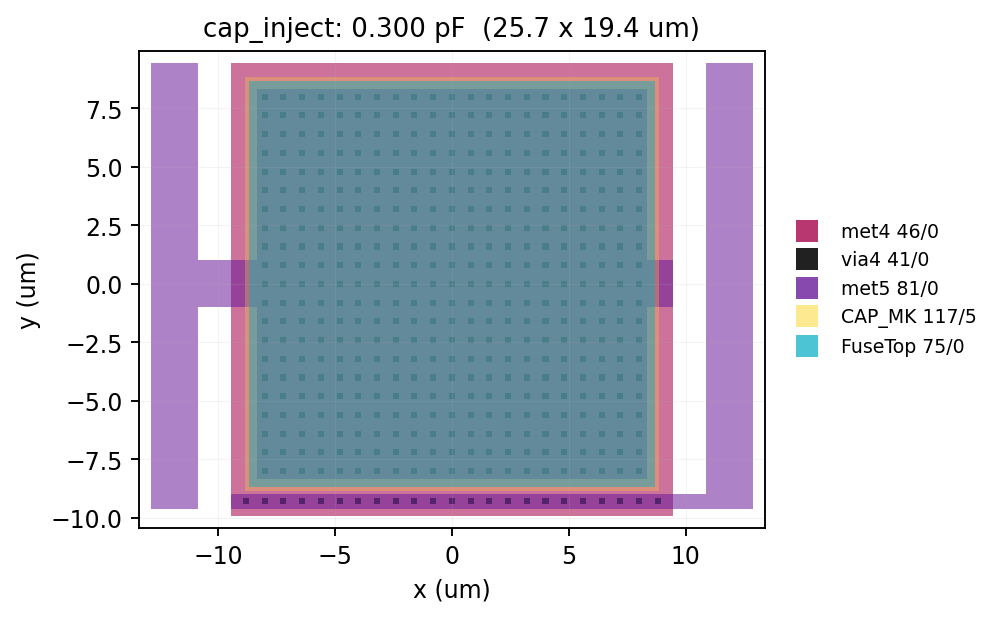

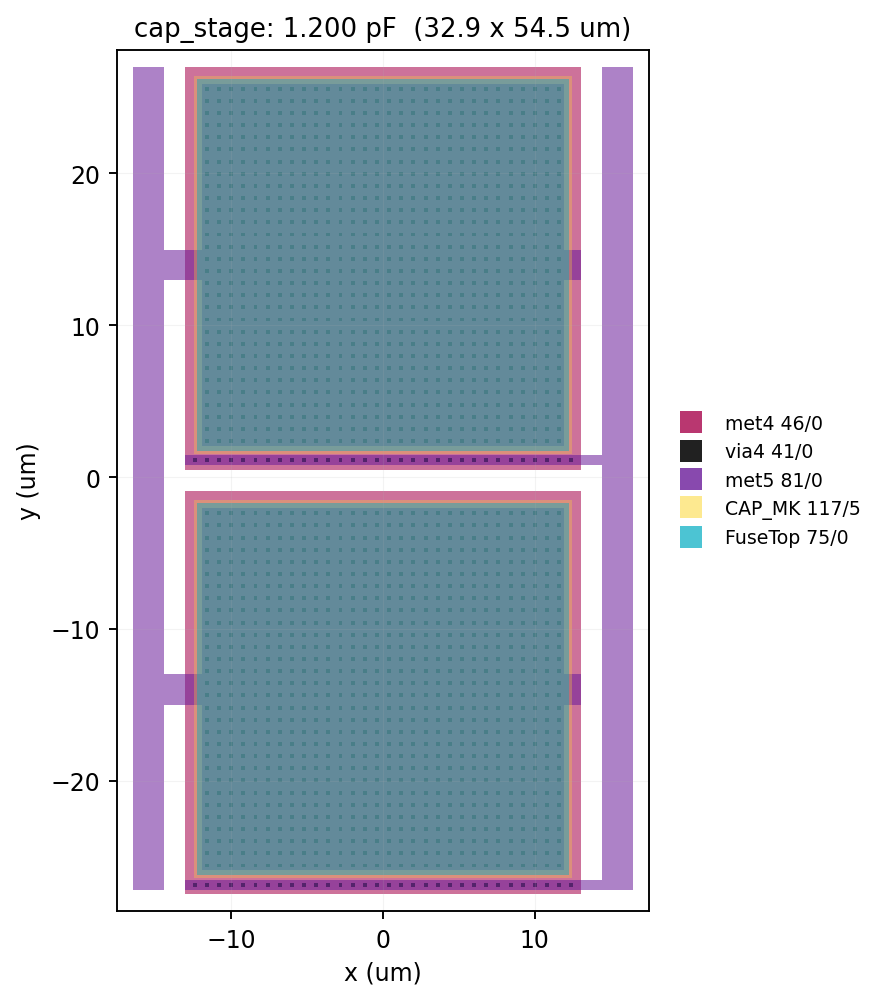

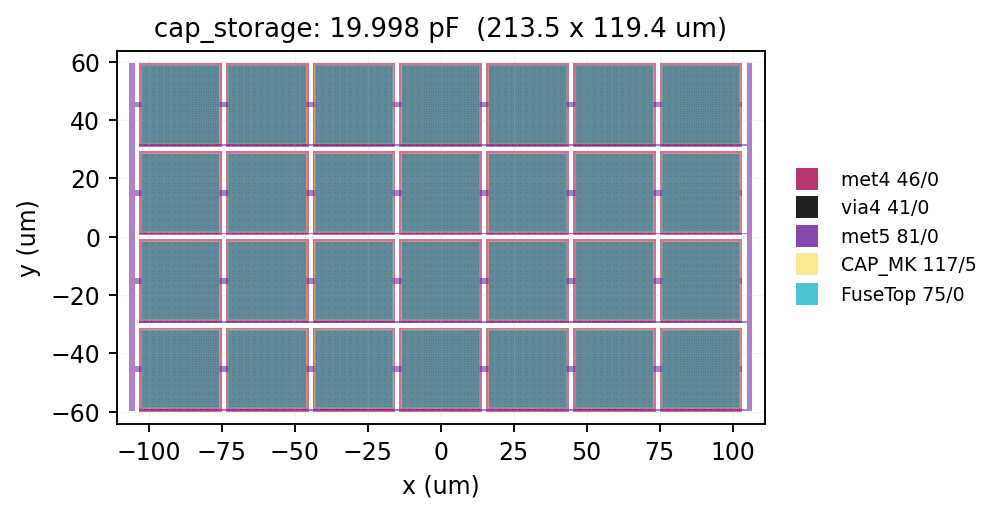

In [25]:
for nm in banks: display(Image(filename=str(IMG / f"ip_cap_{nm}.png")))

In [26]:
for nm, b in banks.items():
    gds = OUT / f"ip_cap_{nm}.gds"
    ok, items = foundry_drc(gds, b.name, f"cap_{nm}")
    tp = b.ports["TOP_stub_N"].center; bp = b.ports["BOT_stub_S"].center
    nets = plate_check(gds, {"top": ("met5", float(tp[0]), 0.0),
                             "bot": ("met5", float(bp[0]), 0.0)}, verbose=False)
    sep = nets["top"] is not None and nets["bot"] is not None and nets["top"] != nets["bot"]
    print(f"{nm:8s} DRC {'CLEAN' if ok else items}   plates separate: {sep}")

inject   DRC CLEAN   plates separate: True


stage    DRC CLEAN   plates separate: True


storage  DRC CLEAN   plates separate: True


---
## Part 5 — Top-level assembly

`harvester_top` interleaved the capacitors with the active blocks and ran the chip rails on
met4 straight across them. That cannot work with real MIM-B capacitors: their bottom plates
**are** met4, their terminals **are** met5, and MIMTM.1 keeps every other met4 1.2 µm clear of
a plate. `top_v2` bands the floorplan instead:

| y (µm) | contents |
|---|---|
| 296 – 536 | active blocks, the met4 chip rails, and a second rail band above the blocks |
| 185 – 296 | riser channel — cap met5 buses climb here and step down to met4 |
| 40 – 185 | capacitor field: met4 bottom plates, met5 terminals |

### Three routing rules this forced, each found by a shorted net

1. **Block ports drop on met3, never met4.** `mlink` draws each stub on the *port's own* layer,
   and several block ports are already met4 — so a vertical drop ran through the intervening
   met4 rails and welded five of them into one 322 × 102 µm polygon.
2. **Route each port the way it faces.** `PUMP_N1_bar_S` / `N2_bar_S` sit at y ≈ 444, *inside*
   the pump and above its own met3 VSS bar at y ≈ 434; dropping them downward crossed that bar
   and shorted N1/N2 to VSS. They now go up to a top rail band and tie down on met5.
3. **Every capacitor needs its own x column.** Each MIM-B array carries a met5 TOP bus on its
   left edge and a BOT bus on its right; `st1` and `in1` shared an x, so their buses landed on
   each other and merged N1 with VMID1.

[mimcap_b] 20.0 pF -> 4x7 of 26.725 um square = 19.998 pF  (213.5 x 119.4 um)
[mimcap_b] 1.2 pF -> 2x1 of 24.495 um square = 1.200 pF  (32.9 x 54.5 um)
[mimcap_b] 1.2 pF -> 2x1 of 24.495 um square = 1.200 pF  (32.9 x 54.5 um)
[mimcap_b] 0.3 pF -> 1x1 of 17.320 um square = 0.300 pF  (25.7 x 19.4 um)
[mimcap_b] 0.3 pF -> 1x1 of 17.320 um square = 0.300 pF  (25.7 x 19.4 um)


core: 416.44 x 496.85 um
caps: [('sto', 'VSS', 'VOUT', 19.998), ('st1', 'RFN', 'N1', 1.2), ('st2', 'RFP', 'N2', 1.2), ('in1', 'RFP', 'VMID1', 0.3), ('in2', 'RFN', 'VMID2', 0.3)]


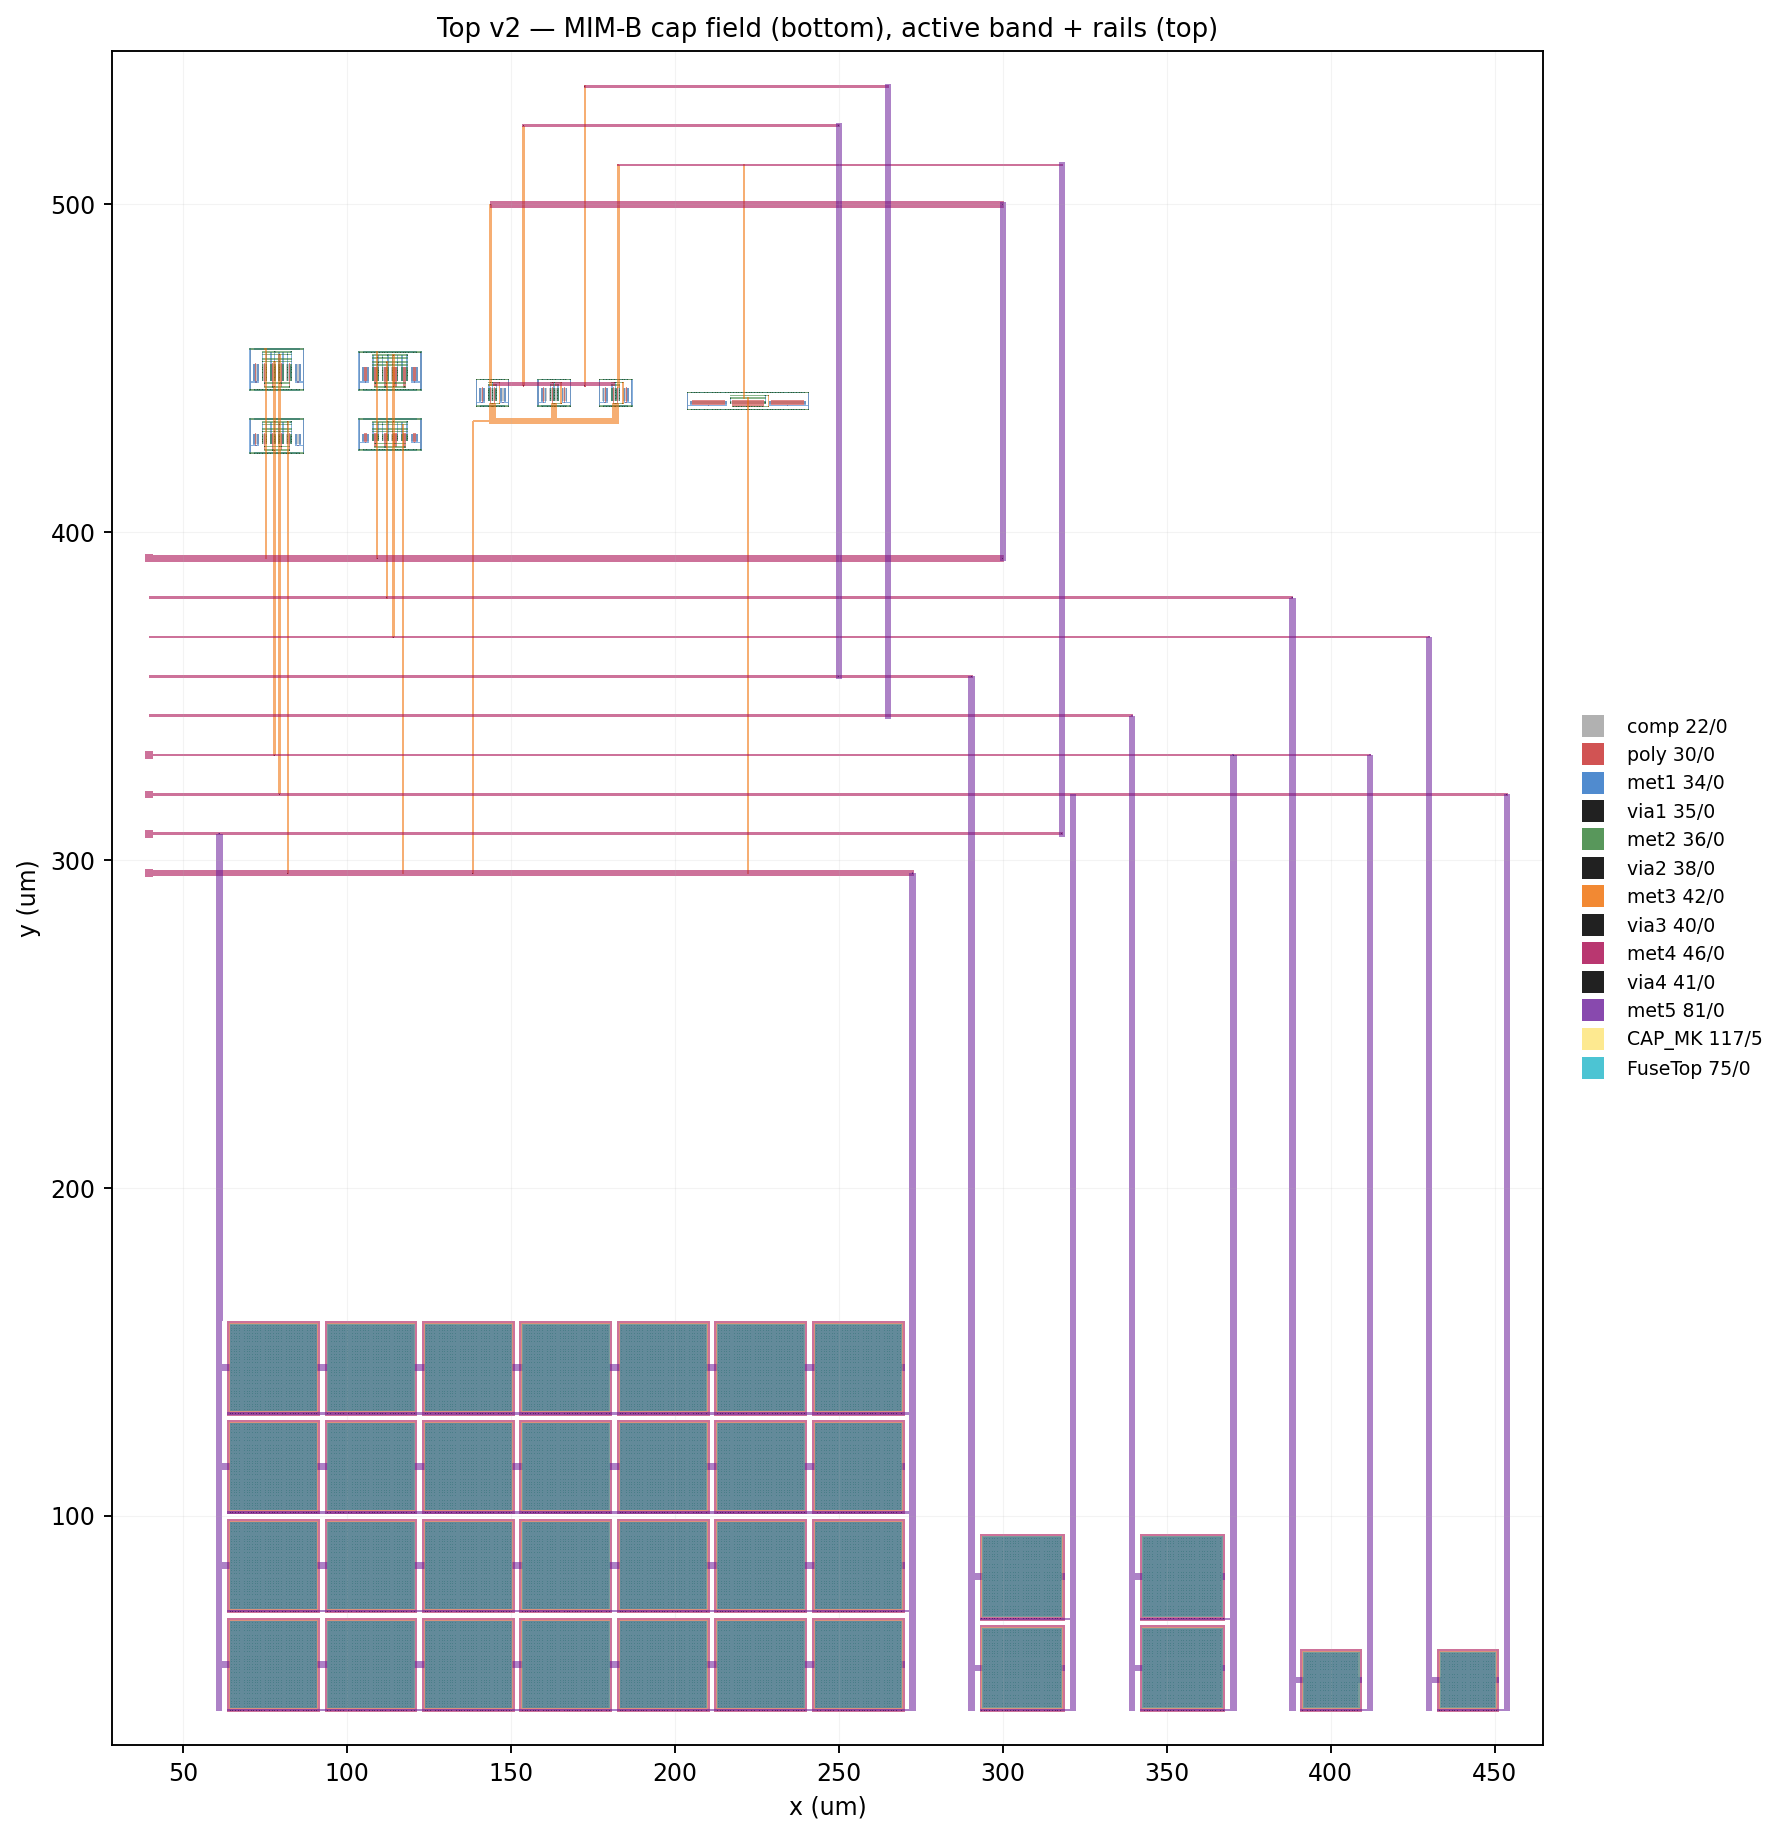

In [27]:
import top_v2
core = top_v2.build(PDK, CONFIG, g, with_caps=True)
w, h = evaluate_bbox(core)
print(f"core: {w:.2f} x {h:.2f} um")
print("caps:", [(k, a, b, round(v, 3)) for k, a, b, v in core.info["cap_values"]])
gds = OUT / "v2_core_full.gds"; core.write_gds(str(gds))
render(gds, IMG / "30_top_v2.png",
       "Top v2 — MIM-B cap field (bottom), active band + rails (top)", figsize=(10, 11))
display(Image(filename=str(IMG / "30_top_v2.png")))

In [28]:
from net_audit_v2 import audit
print("Whole-core net audit (via4 on FuseTop = met5<->fusetop; fusetop never joins met4):\n")
nets, merged = audit(OUT / "v2_core_full.gds")
print("\nno unintended shorts:", not merged)

Whole-core net audit (via4 on FuseTop = met5<->fusetop; fusetop never joins met4):

  FuseTop plates: 34,   23006.8 um^2 -> 23.007 pF at 1.0 fF/um^2
  via4: 36118 total
    N1       net 5
    N2       net 6
    RFN      net 2
    RFP      net 3
    VMID1    net 7
    VMID2    net 8
    VOUT     net 4
    VRECT    net 9
    VSS      net 1
  9 labelled nets -> 9 distinct

no unintended shorts: True


---
## Part 6 — Slot adapter: routing to the D05 boundary pins

The padring hands each net over as a **Metal2** stub 1 µm inside the project boundary; the core
presents met4 rail pads. `build_chip` routes each net:

```
core met4 pad --met4--> lane x --met3--> pin y --met4--> x=4 --via met2..met4--> Metal2 landing
```

Horizontal runs are met4, vertical lanes met3 (x = 24/40/56/72/88 µm), so the one unavoidable
crossing — RFP and VOUT swap order between core and pads — never puts two nets on one layer.
The core is placed 115 µm east so all five lanes fit in the channel, and `build_chip` now
refuses to build if a lane would fall inside the core.

Part 7's fill runs in the same pass, and the chip-level LVS runs on a flattened copy.

In [29]:
r = run("run_tapeout_v2.py", env=ENV, tail=100000)
keep = [l for l in r.stdout.splitlines()
        if any(k in l for k in ("SLOT", "===", "<-", "sanitized", "LVS", "bbox",
                                "met1 ", "met2 ", "met3 ", "met4 ", "met5 ", "poly2 ",
                                "mimcap_b"))]
print("\n".join(keep))

SLOT: <SlotSpec D05_EH 550x550um origin=(350.0, 1475.0) pins=['VSS', 'RFP', 'RFN', 'VOUT', 'VCC'] m2_obstructions=0>

=== FULL view
[mimcap_b] 20.0 pF -> 4x7 of 26.725 um square = 19.998 pF  (213.5 x 119.4 um)
[mimcap_b] 1.2 pF -> 2x1 of 24.495 um square = 1.200 pF  (32.9 x 54.5 um)
[mimcap_b] 1.2 pF -> 2x1 of 24.495 um square = 1.200 pF  (32.9 x 54.5 um)
[mimcap_b] 0.3 pF -> 1x1 of 17.320 um square = 0.300 pF  (25.7 x 19.4 um)
[mimcap_b] 0.3 pF -> 1x1 of 17.320 um square = 0.300 pF  (25.7 x 19.4 um)
core met4 rail pads: {'RFP': (39.5, 332.0), 'RFN': (39.5, 320.0), 'VRECT': (39.5, 392.0), 'VOUT': (39.5, 308.0), 'VSS': (39.5, 296.0)}
  VSS   <- VSS    core met4 pad ( 116.20, 282.57)  lane x= 24.0  -> Metal2 pin y= 42.50  (dy -240.07 um)  [power]
  RFP   <- RFP    core met4 pad ( 116.20, 318.57)  lane x= 40.0  -> Metal2 pin y=142.50  (dy -176.07 um)
  RFN   <- RFN    core met4 pad ( 116.20, 306.57)  lane x= 56.0  -> Metal2 pin y=242.50  (dy  -64.07 um)
  VOUT  <- VOUT   core met4 pad ( 1

---
## Part 7 — Dummy fill

Metal and poly coverage in the slot was 0.1–11 %, against a foundry floor of **30 % metal and
14 % poly** (`M1.4`, `M2.4`, `M3.4`, `M4.4`, `M5.4`, `MT.3`, `PL.8`, whose text reads
*"Customer needs to ensure enough dummy metal"*). `fill.py` tiles the free area on each layer,
clear of everything already on that layer, the slot edge, the Metal2 corner keep-outs and the
pin landings. met4 uses a **1.4 µm** clearance rather than 0.3 because MIMTM.1 keeps any Metal4
1.2 µm off a MIM bottom plate.

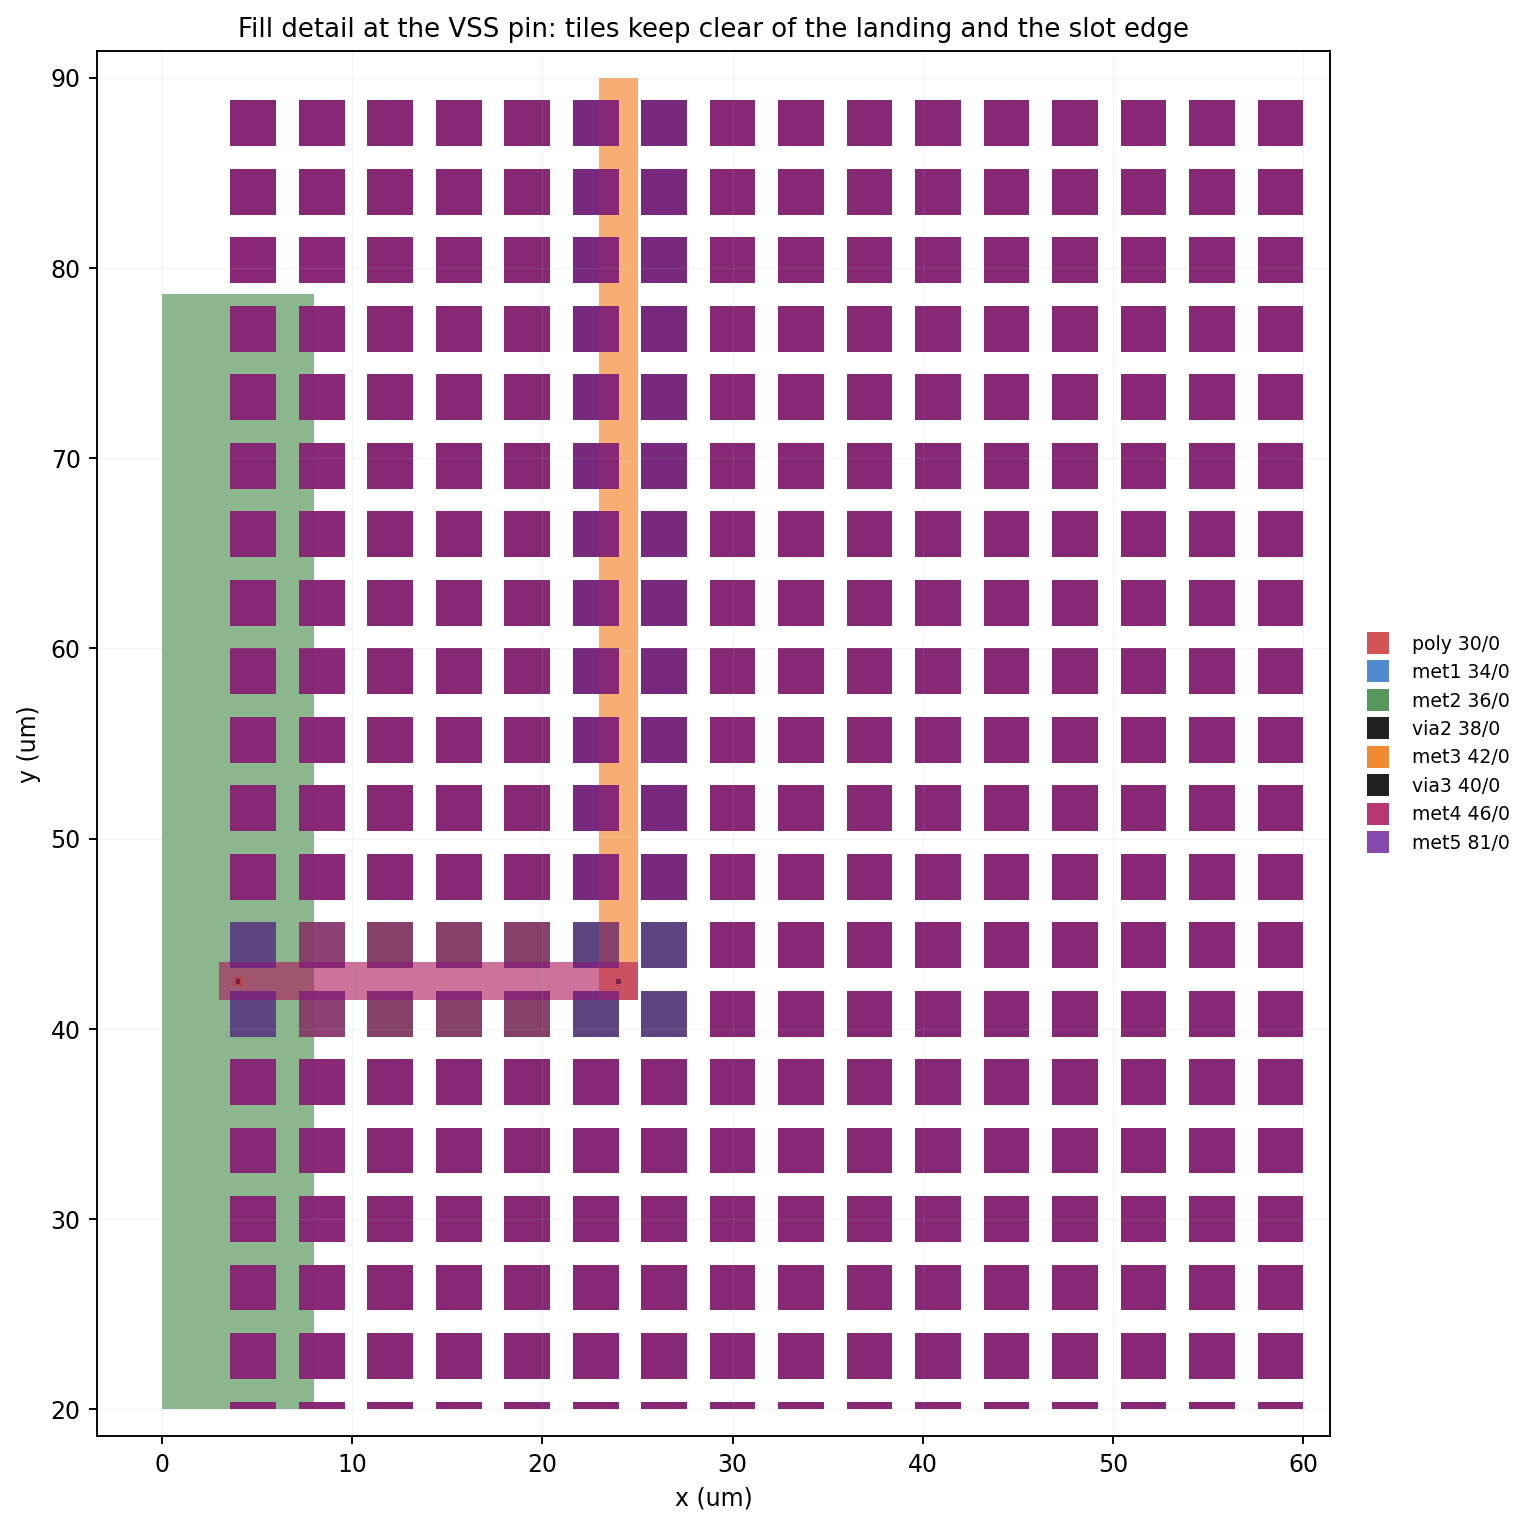

In [30]:
display(Image(filename=str(IMG / "21_fill_detail.png")))

---
## Part 8 — Sign-off on the exact shipped file

In [31]:
import tempfile, glob, collections
import xml.etree.ElementTree as ET
rundir = Path(tempfile.mkdtemp(prefix="d05sign_"))
deck = Path(PDK_ROOT) / "gf180mcuD" / "libs.tech" / "klayout" / "drc" / "run_drc.py"
r = subprocess.run([sys.executable, str(deck), f"--path={OUT/'D05_Gelochip.gds'}",
                    "--variant=D", "--topcell=D05_Gelochip", f"--run_dir={rundir}",
                    "--mp=4", "--density", "--antenna"],
                   capture_output=True, text=True, env=ENV_NOPP, cwd=str(rundir))
log = r.stdout + r.stderr
print([l.split("| ")[-1] for l in log.splitlines() if "DRC run is clean" in l][-1:])
print(sorted({l.split(": ")[-1] for l in log.splitlines() if "MIM Option selected" in l}))
print(sorted({"fusetop " + l.split("fusetop ")[-1] for l in log.splitlines() if "fusetop has" in l}))
tot = collections.Counter()
for f in glob.glob(str(rundir / "*.lyrdb")):
    try: root = ET.parse(f).getroot()
    except Exception: continue
    for it in root.iter("item"):
        c = (it.findtext("category") or "").strip("'\"")
        if c: tot[c] += 1
print(f"\nFLAGGED ITEMS (geometry + density + antenna): {sum(tot.values())}")
for k, v in tot.most_common(20): print("   ", k, v)

['Klayout DRC run is clean. GDS has no DRC violations.']
['B']
['fusetop has 34 polygons']

FLAGGED ITEMS (geometry + density + antenna): 0


In [32]:
# every MIM must have two distinct plate nets -- a capacitor, not a via stack
from net_audit_v2 import extract
ly2, top2, l2n2, R2 = extract(OUT / "D05_Gelochip.gds")
ft = kdb.Region(top2.shapes(ly2.layer(75, 0))); ft.merge()
bad = 0
for pg in ft.each():
    b = pg.bbox(); cx, cy = b.center().x*ly2.dbu, b.center().y*ly2.dbu
    a = l2n2.probe_net(R2["fusetop"], kdb.DPoint(cx, cy))
    c = l2n2.probe_net(R2["met4"],    kdb.DPoint(cx, cy))
    if a is None or c is None or a.cluster_id == c.cluster_id: bad += 1
print(f"FuseTop plates: {ft.count()}, total {ft.area()*ly2.dbu*ly2.dbu:.1f} um^2 "
      f"-> {ft.area()*ly2.dbu*ly2.dbu/1000:.3f} pF")
print(f"plates shorted or floating: {bad}")
print("every MIM has two distinct plate nets:", bad == 0)

FuseTop plates: 34, total 23006.8 um^2 -> 23.007 pF
plates shorted or floating: 0
every MIM has two distinct plate nets: True


In [33]:
run("variant_check.py", env=ENV_NOPP)

GDS D05_Gelochip.gds   top=D05_Gelochip   bbox=(0.0,0.0)-(550.0,550.0)
This GDS was BUILT FOR variant EH: its Metal2 landings sit on EH's pin bands.

--- variant D  [info only]  origin (350.0, 2035.0), pins on W edge ---
    keep-out ( 529.00, 548.00)-( 550.00, 550.00)  CLEAR (nearest Metal2 > 0 um away)
    keep-out (   0.00,   0.00)-(   2.00,  21.00)  29.2800 um^2 of Metal2 inside -- NOT a violation of this build: rebuild with D05_VARIANT=D and the landings move

--- variant EH  [BUILT]  origin (350.0, 1475.0), pins on W edge ---
    no Metal2 corner obstruction issued for this slot -> nothing to check
--- variant EV  [info only]  origin (910.0, 2035.0), pins on N edge ---
    no Metal2 corner obstruction issued for this slot -> nothing to check
VERDICT for the built variant (EH): CLEAR - no Metal2 in any issued keep-out
Note: D would need a rebuild before their keep-outs apply (verified separately).



CompletedProcess(args=['/home/irman/miniconda3/envs/glayout_env/bin/python', '/home/irman/gLayout/notebook/tapeout/variant_check.py'], returncode=0, stdout="GDS D05_Gelochip.gds   top=D05_Gelochip   bbox=(0.0,0.0)-(550.0,550.0)\nThis GDS was BUILT FOR variant EH: its Metal2 landings sit on EH's pin bands.\n\n--- variant D  [info only]  origin (350.0, 2035.0), pins on W edge ---\n    keep-out ( 529.00, 548.00)-( 550.00, 550.00)  CLEAR (nearest Metal2 > 0 um away)\n    keep-out (   0.00,   0.00)-(   2.00,  21.00)  29.2800 um^2 of Metal2 inside -- NOT a violation of this build: rebuild with D05_VARIANT=D and the landings move\n\n--- variant EH  [BUILT]  origin (350.0, 1475.0), pins on W edge ---\n    no Metal2 corner obstruction issued for this slot -> nothing to check\n--- variant EV  [info only]  origin (910.0, 2035.0), pins on N edge ---\n    no Metal2 corner obstruction issued for this slot -> nothing to check\n==========================================================================

### 8b — split nets, dangling metal, and capacitor net assignment

Three checks that catch what DRC and LVS structurally cannot.

* **Split nets.** LVS runs on the capacitor-free view, and a net-audit that probes only the
  *first* label of each name cannot see a net broken into two pieces that both carry that name.
  This walks every routing polygon and reports, per net, which names it carries. A name
  appearing on two nets is a broken rail. (This is how VOUT and VRECT were found split: the
  bottom rail did not reach the met5 tie column, so the tie landed on an isolated pad.)
* **Dangling metal.** Any routing polygon not reachable from one of the nine named nets is a
  route that goes nowhere. Fill tiles are floating by design, so this runs on the pre-fill
  topology. Note the probe must use a point genuinely *inside* each polygon — a merged L or
  comb shape has its bbox centre outside the metal, which reads as a false orphan.
* **Capacitor net assignment.** Plate separation only proves a capacitor is not a short. This
  proves each capacitor sits on the two nets it is *supposed* to, by naming the net each plate
  reaches. Probing a multi-tile bank at its bbox centre lands in the gap between tiles, so each
  CAP_MK tile is probed individually.

In [34]:
r = subprocess.run([sys.executable, str(TAPEOUT/"dangling_check.py"),
                    str(OUT/"D05_Gelochip_nofill.gds")],
                   capture_output=True, text=True, env=ENV_NOPP, cwd=str(NBDIR))
print(r.stdout[-4000:] or r.stderr[-2000:])

     net  names                      shapes per layer
----------------------------------------------------------------------------------------
       1  VSS                        {'met1': 33, 'met2': 27, 'met3': 6, 'met4': 30, 'met5': 1}
       4  VOUT                       {'met1': 15, 'met2': 7, 'met3': 5, 'met4': 3, 'met5': 2, 'fusetop': 28}
       9  VCC,VRECT                  {'met1': 18, 'met2': 20, 'met3': 6, 'met4': 3, 'met5': 1}
       3  RFP                        {'met1': 8, 'met2': 9, 'met3': 3, 'met4': 5, 'met5': 2}
       2  RFN                        {'met1': 8, 'met2': 9, 'met3': 3, 'met4': 5, 'met5': 2}
       5  N1                         {'met1': 4, 'met2': 6, 'met3': 4, 'met4': 3, 'met5': 2, 'fusetop': 2}
       6  N2                         {'met1': 4, 'met2': 6, 'met3': 4, 'met4': 3, 'met5': 2, 'fusetop': 2}
       8  VMID2                      {'met1': 8, 'met2': 8, 'met3': 1, 'met4': 1, 'met5': 1, 'fusetop': 1}
       7  VMID1                      {'met1': 8, '

In [35]:
run("cap_net_check.py", env=ENV_NOPP)

bank   tiles      probe tile centre  TOP plate net          BOT plate net         
----------------------------------------------------------------------------------------------------
0         28 (   213.72,   101.58)  ['VOUT']               ['VSS']               
1          2 (   382.65,    68.05)  ['N1']                 ['RFN']               
2          2 (   431.55,    68.05)  ['N2']                 ['RFP']               
3          1 (   476.86,    36.49)  ['VMID1']              ['RFP']               
4          1 (   518.58,    36.49)  ['VMID2']              ['RFN']               
----------------------------------------------------------------------------------------------------

expected cap net pairs: [('RFN', 'N1'), ('RFN', 'VMID2'), ('RFP', 'N2'), ('RFP', 'VMID1'), ('VSS', 'VOUT')]
observed (bottom, top) : [(('RFN',), ('N1',)), (('RFN',), ('VMID2',)), (('RFP',), ('N2',)), (('RFP',), ('VMID1',)), (('VSS',), ('VOUT',))]

all capacitors wired to NAMED nets on both plates: True


CompletedProcess(args=['/home/irman/miniconda3/envs/glayout_env/bin/python', '/home/irman/gLayout/notebook/tapeout/cap_net_check.py'], returncode=0, stdout="bank   tiles      probe tile centre  TOP plate net          BOT plate net         \n----------------------------------------------------------------------------------------------------\n0         28 (   213.72,   101.58)  ['VOUT']               ['VSS']               \n1          2 (   382.65,    68.05)  ['N1']                 ['RFN']               \n2          2 (   431.55,    68.05)  ['N2']                 ['RFP']               \n3          1 (   476.86,    36.49)  ['VMID1']              ['RFP']               \n4          1 (   518.58,    36.49)  ['VMID2']              ['RFN']               \n----------------------------------------------------------------------------------------------------\n\nexpected cap net pairs: [('RFN', 'N1'), ('RFN', 'VMID2'), ('RFP', 'N2'), ('RFP', 'VMID1'), ('VSS', 'VOUT')]\nobserved (bottom, top) : [(('

### 8c — padring handover and route widths

Does our Metal2 actually cover every DEF pin rectangle of variant EH, and is every wire above
its DRC minimum width?

In [36]:
run("padring_check.py", env=ENV_NOPP)

1. PADRING HANDOVER — does our Metal2 cover every DEF pin rectangle of variant EH?
pin    pad   DEF rects  required area  our met2 there  labelled  verdict
VSS    W12           6       60.000um2        60.000um2      True  LANDED
RFP    W13           8       20.320um2        20.320um2      True  LANDED
RFN    W14           8       20.320um2        20.320um2      True  LANDED
VOUT   W15           8       20.320um2        20.320um2      True  LANDED
VCC    W16           6       60.000um2        60.000um2      True  LANDED

every DEF pin rectangle fully covered and labelled: True

2. ROUTE WIDTHS — min dimension of every merged shape per layer
layer    shapes  DRC min  actual min   median       max   most common widths
met1      22736     0.23       0.500    2.400      5.68   2.4:22630, 0.5:90, 2.77:10, 3.19:4, 5.68:2
met2      22596     0.28       0.500    2.400      8.00   2.4:22496, 0.5:95, 8.0:5
met3      22066     0.28       0.500    2.400     44.96   2.4:22033, 0.5:13, 0.8:10, 2.0:5

CompletedProcess(args=['/home/irman/miniconda3/envs/glayout_env/bin/python', '/home/irman/gLayout/notebook/tapeout/padring_check.py'], returncode=0, stdout='========================================================================================================\n1. PADRING HANDOVER — does our Metal2 cover every DEF pin rectangle of variant EH?\n========================================================================================================\npin    pad   DEF rects  required area  our met2 there  labelled  verdict\nVSS    W12           6       60.000um2        60.000um2      True  LANDED\nRFP    W13           8       20.320um2        20.320um2      True  LANDED\nRFN    W14           8       20.320um2        20.320um2      True  LANDED\nVOUT   W15           8       20.320um2        20.320um2      True  LANDED\nVCC    W16           6       60.000um2        60.000um2      True  LANDED\n\nevery DEF pin rectangle fully covered and labelled: True\n\n====================================

GDS AUDIT
  file          : D05_Gelochip.gds
  top cell      : D05_Gelochip
  cells         : 163 (hierarchical: True )
  bad names     : none
  bbox          : (0.0,0.0)-(550.0,550.0) um
  0/0 boundary  : present


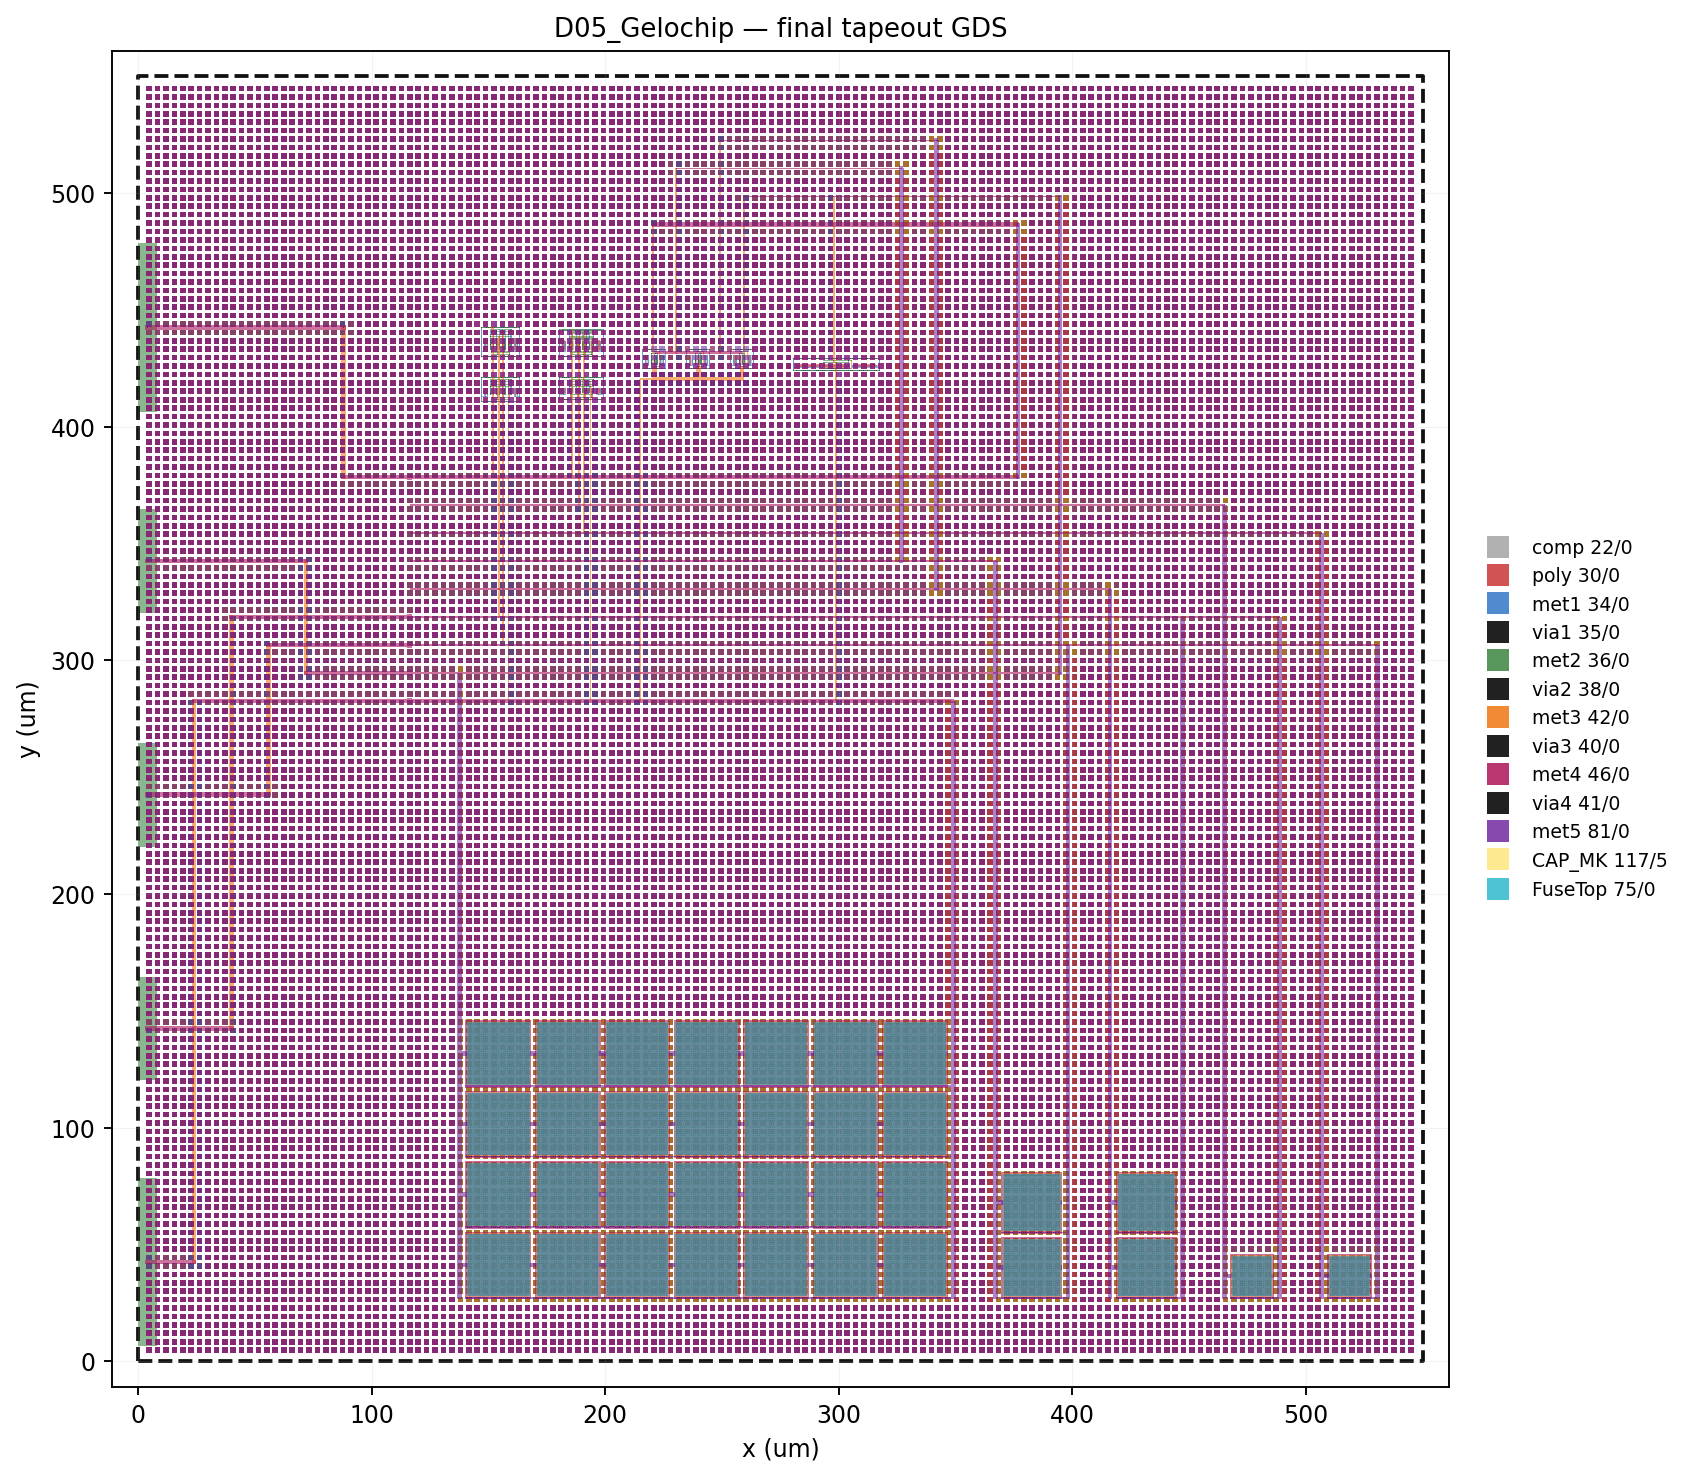

In [37]:
ly3 = kdb.Layout(); ly3.read(str(OUT / "D05_Gelochip.gds")); t3 = ly3.top_cell(); bb3 = t3.dbbox()
cells = [c.name for c in ly3.each_cell()]
print("GDS AUDIT")
print("  file          :", (OUT / "D05_Gelochip.gds").name)
print("  top cell      :", t3.name)
print("  cells         :", len(cells), "(hierarchical:", len(cells) > 1, ")")
print("  bad names     :", [c for c in cells if not c.replace("_", "").isalnum()][:3] or "none")
print(f"  bbox          : ({bb3.left:.1f},{bb3.bottom:.1f})-({bb3.right:.1f},{bb3.top:.1f}) um")
print("  0/0 boundary  :", "present" if ly3.find_layer(0, 0) is not None else "MISSING")
render(OUT / "D05_Gelochip.gds", IMG / "40_final_chip.png",
       "D05_Gelochip — final tapeout GDS", figsize=(10, 10))
display(Image(filename=str(IMG / "40_final_chip.png")))

### 8d — independent cross-check render

The same three views again through KLayout's own engine. The filled view is dominated by dummy
fill, so the no-fill topology is shown next to it — that is the one to read the routing from.

final tapeout GDS (with fill)


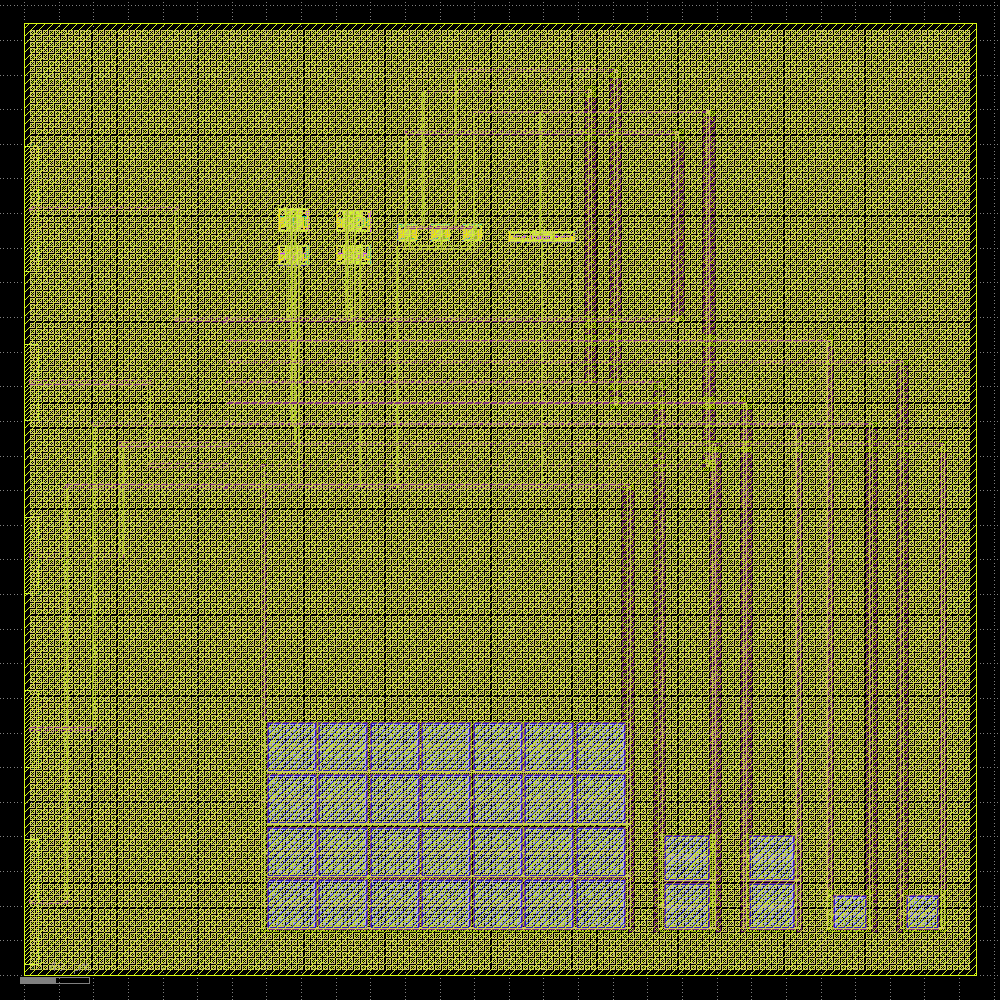

same topology, fill removed — read the routing here


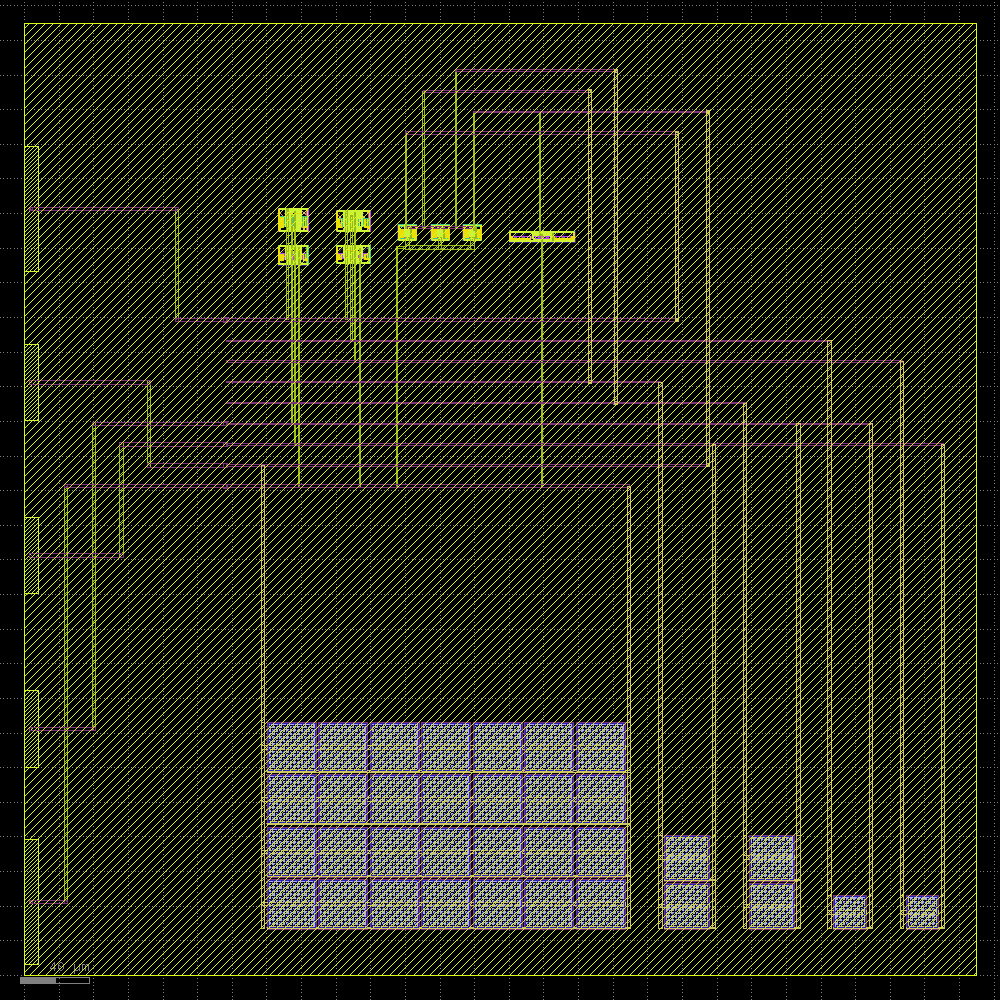

core only


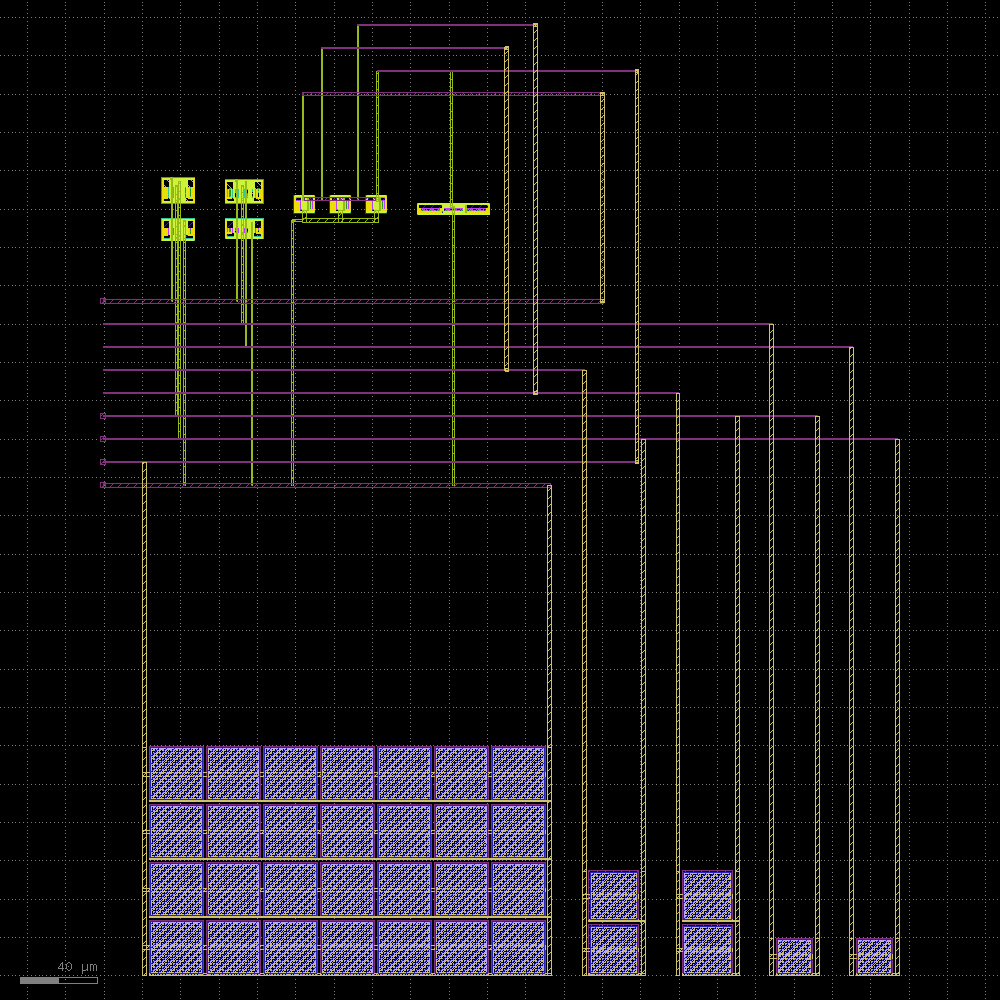

In [38]:
for src, out, cap in ((OUT/"D05_Gelochip.gds",        "60_final_klayout.png",  "final tapeout GDS (with fill)"),
                      (OUT/"D05_Gelochip_nofill.gds", "61_nofill_klayout.png", "same topology, fill removed — read the routing here"),
                      (OUT/"v2_core_full.gds",        "63_core_klayout.png",   "core only")):
    klayout_png(src, IMG / out, width=1000, height=1000)
    print(cap)
    display(Image(filename=str(IMG / out)))

---
## Part 9 — PEX extraction

magic extracts the **FET view** with `extresist` interconnect resistance and `cthresh 0`
parasitic capacitance; every labelled net becomes a subckt port. The FET view is used because
magic's `gf180mcuD` tech has no MIM device — it would read the via4 sea on FuseTop as a plate
short. The capacitors are therefore re-inserted in the testbench at the values the MIM-B banks
actually realise (Part 4.7), not at their nominal targets.

In [39]:
core_fet = top_v2.build(PDK, CONFIG, g, with_caps=False)
flat_fet = core_fet.flatten(); flat_fet.name = "RFEH_PEX"
flat_fet.info["netlist"] = core_fet.info["netlist"]
pex_path = g["run_pex"](flat_fet, extresist=True)
sub = next(l for l in open(pex_path) if l.startswith(".subckt")).strip()
PEX_PORTS = sub.split()[2:]
print("subckt:", sub[:150])
print("ports :", PEX_PORTS)
print("lines :", sum(1 for _ in open(pex_path)))

PEX  RFEH_PEX: OK -> /home/irman/gLayout/notebook/rf_harvester_tapeout_out/RFEH_PEX_pex.spice
subckt: .subckt RFEH_PEX VRECT RFP RFN VSS VOUT N1 N2 VMID1 VMID2
ports : ['VRECT', 'RFP', 'RFN', 'VSS', 'VOUT', 'N1', 'N2', 'VMID1', 'VMID2']
lines : 2795


In [40]:
# capacitor values as actually built by the MIM-B banks
CAPS = core.info["cap_values"]
cap_lines = "\n".join(f"C{n} {a} {b} {v:.4f}p" for n, a, b, v in CAPS)
print("testbench capacitors (from the MIM-B geometry):")
print(cap_lines)
print(f"\ntotal on-chip MIM capacitance: {sum(v for *_ , v in CAPS):.3f} pF")

testbench capacitors (from the MIM-B geometry):
Csto VSS VOUT 19.9983p
Cst1 RFN N1 1.2000p
Cst2 RFP N2 1.2000p
Cin1 RFP VMID1 0.3000p
Cin2 RFN VMID2 0.3000p

total on-chip MIM capacitance: 22.998 pF


---
## Part 10 — Post-layout transient

±0.9 V, 30 MHz differential RF in, on the extracted netlist with full RC parasitics.

In [41]:
XDUT = "XDUT " + " ".join(PEX_PORTS) + " RFEH_PEX"
if NGSPICE_BIN is None:
    print("SKIP: no ngspice >= 39 available")
else:
    shutil.copy(pex_path, os.path.join(SIMDIR, "rfeh_pex.spice"))
    tb = f'''* RF energy harvester - post-layout (PEX) transient
.temp 27
.include {SIM_PDKPATH}/libs.tech/ngspice/design.ngspice
.lib {SIM_PDKPATH}/libs.tech/ngspice/sm141064.ngspice typical
.include rfeh_pex.spice

{XDUT}
{cap_lines}

VVSS VSS 0 0
VSUB VSUBS 0 0
VRFP RFP 0 SIN(0 0.9 30MEG 0 0 0)
VRFN RFN 0 SIN(0 0.9 30MEG 0 0 180)
.GLOBAL VSUBS

.control
tran 1n 10u
meas tran vrect_final find v(VRECT) at=9.99u
meas tran vout_final  find v(VOUT)  at=9.99u
wrdata rfeh_tran.csv v(VOUT) v(VRECT) v(N2) v(VMID1)
.endc
.end
'''
    open(os.path.join(SIMDIR, "rfeh_tb.sp"), "w").write(tb)
    t0 = time.time()
    r = subprocess.run([NGSPICE_BIN, "-b", "rfeh_tb.sp"], capture_output=True,
                       text=True, cwd=SIMDIR, timeout=900)
    for l in r.stdout.splitlines():
        if "final" in l: print(l.strip())
    print(f"ngspice rc={r.returncode} in {time.time()-t0:.0f}s")
    if r.returncode != 0: print(r.stderr[-1500:])

vrect_final         =  8.15955e-01
vout_final          =  1.57673e+00
ngspice rc=0 in 12s


In [42]:
import numpy as np, matplotlib.pyplot as plt
csv = os.path.join(SIMDIR, "rfeh_tran.csv")
if NGSPICE_BIN and os.path.exists(csv):
    d = np.loadtxt(csv)
    t, vout, vrect, vn2 = d[:, 0]*1e6, d[:, 1], d[:, 3], d[:, 5]
    tail = t > (t[-1] - 1.0)                 # last microsecond -- RF ripple averages out
    vo_f, vr_f = vout[tail].mean(), vrect[tail].mean()
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(t, vout,  label=f"VOUT (settled {vo_f:.2f} V)", lw=1.8)
    ax.plot(t, vrect, label=f"VRECT (settled {vr_f:.2f} V)", lw=1.2)
    ax.plot(t, vn2,   label="N2 (pump node)", lw=0.6, alpha=0.6)
    ax.set_xlabel("time (µs)"); ax.set_ylabel("V")
    ax.set_title("Post-layout (PEX) startup transient — ±0.9 V @ 30 MHz differential")
    ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()
    print(f"Pump gain VOUT/VRECT = {vo_f/vr_f:.2f}  (Dickson doubler, ~2x expected)")
    SIM = {"vout": vo_f, "vrect": vr_f}
else:
    SIM = {}
    print("no transient data")

Pump gain VOUT/VRECT = 2.45  (Dickson doubler, ~2x expected)


---
## Part 11 — Parasitic audit

Two machine checks that the extraction is *correct* and the chip is *fully wired*.

1. **Device parameters** — the (model, W, L) histogram from the schematic must equal the one
   magic extracted. LVS already proved topology; this proves the parameters, and reports how
   many parasitic R and C elements the extraction produced.
2. **Capacitor plates** — every MIM must present two distinct nets. This uses the layer-aware
   model from Part 3, not magic, because magic cannot see a MIM at all.

In [43]:
ext_txt = open(pex_path).read()

def flat_histo(netlist_text):
    # Expand the subckt hierarchy: a subckt instantiated N times contributes N x
    # its device cards (times any m= multiplier).
    subckts, order, cur = {}, [], None
    for ls in (l.strip() for l in netlist_text.splitlines()):
        if ls.startswith(".subckt"):
            cur = ls.split()[1]; subckts[cur] = []; order.append(cur)
        elif ls.startswith(".ends"):
            cur = None
        elif ls.startswith("X") and cur is not None:
            m = re.search(r"\s(nfet_03v3|pfet_03v3)\s+l=([\d.]+)\s+w=([\d.]+)(?:\s+m=(\d+))?", ls)
            if m:
                subckts[cur].append(("DEV", (m.group(1), float(m.group(3)), float(m.group(2))),
                                     int(m.group(4) or 1)))
            else:
                subckts[cur].append(("SUB", [t for t in ls.split() if "=" not in t][-1], 1))
    memo = {}
    def expand(name):
        if name not in memo:
            h = {}
            for kind, ref, mult in subckts.get(name, []):
                if kind == "DEV":
                    h[ref] = h.get(ref, 0) + mult
                else:
                    for k, v in expand(ref).items():
                        h[k] = h.get(k, 0) + v*mult
            memo[name] = h
        return memo[name]
    return expand(order[-1])

sch_h = flat_histo(core_fet.info["netlist"].generate_netlist())
ext_h = {}
for m in re.finditer(r"^X\S+ .* (nfet_03v3|pfet_03v3) .*?w=([\d.]+)u l=([\d.]+)u", ext_txt, re.M):
    k = (m.group(1), float(m.group(2)), float(m.group(3)))
    ext_h[k] = ext_h.get(k, 0) + 1
print(f"{'model':10s} {'W(um)':>6s} {'L(um)':>6s} {'schem':>6s} {'extracted':>9s}")
qc_ok = True
for k in sorted(set(sch_h) | set(ext_h)):
    a, b = sch_h.get(k, 0), ext_h.get(k, 0)
    qc_ok &= (a == b)
    print(f"{k[0]:10s} {k[1]:6.2f} {k[2]:6.2f} {a:6d} {b:9d}  {'OK' if a == b else '**MISMATCH**'}")
n_r = sum(1 for l in ext_txt.splitlines() if l.startswith("R"))
n_c = sum(1 for l in ext_txt.splitlines() if l.startswith("C"))
print(f"\nparasitics extracted: {n_r} resistors (extresist), {n_c} capacitors (cthresh 0)")
print("PEX parameter check:", "PASS" if qc_ok else "FAIL")
N_FETS = sum(sch_h.values())

model       W(um)  L(um)  schem extracted
nfet_03v3    1.00  10.00      3         3  OK
nfet_03v3    2.00   1.00      6         6  OK
nfet_03v3    3.00   0.28      6         6  OK
nfet_03v3    4.00   0.28     12        12  OK
pfet_03v3    4.00   1.00      6         6  OK
pfet_03v3    5.00   0.28      6         6  OK

parasitics extracted: 2303 resistors (extresist), 448 capacitors (cthresh 0)
PEX parameter check: PASS


In [44]:
from net_audit_v2 import extract as _extract
lyq, topq, l2nq, Rq = _extract(OUT / "D05_Gelochip.gds")
ftq = kdb.Region(topq.shapes(lyq.layer(75, 0))); ftq.merge()
bad = 0
for pg in ftq.each():
    b = pg.bbox(); cx, cy = b.center().x*lyq.dbu, b.center().y*lyq.dbu
    a = l2nq.probe_net(Rq["fusetop"], kdb.DPoint(cx, cy))
    c = l2nq.probe_net(Rq["met4"],    kdb.DPoint(cx, cy))
    if a is None or c is None or a.cluster_id == c.cluster_id: bad += 1
print(f"MIM plates: {ftq.count()}  total {ftq.area()*lyq.dbu*lyq.dbu:.1f} um^2 "
      f"= {ftq.area()*lyq.dbu*lyq.dbu/1000:.3f} pF")
print(f"plates shorted or floating: {bad}")
print("cap-plate audit:", "PASS - every MIM has two distinct plate nets" if bad == 0 else "FAIL")

MIM plates: 34  total 23006.8 um^2 = 23.007 pF
plates shorted or floating: 0
cap-plate audit: PASS - every MIM has two distinct plate nets


---
## Part 12 — Performance sweeps on the PEX netlist

Realistic drive: a differential source with **50 Ω per side** (100 Ω differential), swept by
*available power* P_av in dBm — per-side amplitude √(8·100·P_av)/2. Points run in parallel.

In [45]:
import math
from concurrent.futures import ThreadPoolExecutor

def run_tb(tag, body, controls):
    tb = ("* " + tag + "\n.temp 27\n"
          f".include {SIM_PDKPATH}/libs.tech/ngspice/design.ngspice\n"
          f".lib {SIM_PDKPATH}/libs.tech/ngspice/sm141064.ngspice typical\n"
          ".include rfeh_pex.spice\n" + XDUT + "\n" + cap_lines + "\n"
          "VVSS VSS 0 0\nVSUB VSUBS 0 0\n" + body +
          ".GLOBAL VSUBS\n.control\n" + controls + ".endc\n.end\n")
    open(os.path.join(SIMDIR, f"{tag}.sp"), "w").write(tb)
    subprocess.run([NGSPICE_BIN, "-b", f"{tag}.sp"], capture_output=True,
                   text=True, cwd=SIMDIR, timeout=900)

def vout_settled(tag):
    d = np.loadtxt(os.path.join(SIMDIR, f"{tag}.csv"))
    t, v = d[:, 0], d[:, 1]
    return v[t > t[-1]*0.8].mean()

def amp_for_dbm(dbm, rs_diff=100.0):
    return math.sqrt(8*rs_diff*1e-3*10**(dbm/10))/2

def power_point(dbm, freq=30e6, tag=None, match=""):
    tag = tag or ("pw" + f"{int(dbm):+d}".replace("+", "p").replace("-", "m"))
    a = amp_for_dbm(dbm)
    body = (f"VRFP RFS_P 0 SIN(0 {a:.4f} {freq/1e6}MEG 0 0 0)\n"
            f"VRFN RFS_N 0 SIN(0 {a:.4f} {freq/1e6}MEG 0 0 180)\n"
            f"RSP RFS_P {'MP' if match else 'RFP'} 50\n"
            f"RSN RFS_N {'MN' if match else 'RFN'} 50\n" + match)
    run_tb(tag, body, f"tran 1n 8u\nwrdata {tag}.csv v(VOUT)\n")
    return vout_settled(tag)

DBMS = [-10, -6, -2, 0, 2, 4, 6, 8]
if NGSPICE_BIN:
    t0 = time.time()
    with ThreadPoolExecutor(3) as ex:
        VOUT_UM = list(ex.map(power_point, DBMS))
    print(f"unmatched power sweep ({time.time()-t0:.0f}s):")
    for d_, v_ in zip(DBMS, VOUT_UM):
        print(f"  {d_:+3d} dBm -> VOUT = {v_:.2f} V")
else:
    VOUT_UM = []
    print("SKIP: no ngspice")

unmatched power sweep (32s):
  -10 dBm -> VOUT = 0.00 V
   -6 dBm -> VOUT = 0.00 V
   -2 dBm -> VOUT = 0.07 V
   +0 dBm -> VOUT = 0.31 V
   +2 dBm -> VOUT = 0.67 V
   +4 dBm -> VOUT = 1.06 V
   +6 dBm -> VOUT = 1.49 V
   +8 dBm -> VOUT = 1.93 V


In [46]:
FREQS = [20, 30, 60, 90, 120]
if NGSPICE_BIN:
    t0 = time.time()
    with ThreadPoolExecutor(3) as ex:
        VOUT_F = list(ex.map(lambda f: power_point(0, freq=f*1e6, tag=f"fr{int(f)}"), FREQS))
    fig, ax = plt.subplots(figsize=(7, 3.6))
    ax.plot(FREQS, VOUT_F, "o-")
    ax.set_xlabel("RF frequency (MHz)"); ax.set_ylabel("VOUT (V)")
    ax.set_title("VOUT vs frequency @ 0 dBm available power (50 Ω/side, unmatched)")
    ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
    print(f"({time.time()-t0:.0f}s) the unmatched input is high-Z capacitive, so 50 Ω drive "
          "is broadband -- see Part 13")

(24s) the unmatched input is high-Z capacitive, so 50 Ω drive is broadband -- see Part 13


---
## Part 13 — Large-signal input impedance and matching

The rectifier input is nonlinear, so Z_in is measured **large-signal**: ideal differential
drive, fundamental phasors V₁/I₁ over an integer-cycle steady-state window (single-bin DFT).
An L-section (shunt C across the inputs, series L per side) is solved numerically to transform
Z_in to the 100 Ω differential source, and the power sweep re-runs through it. At 30 MHz the
series inductance is µH-scale, so the match is **off-chip** — normal for a sub-100 MHz
harvester. Z_in is amplitude-dependent; a production match would be re-optimised at the target
input power.

In [47]:
if NGSPICE_BIN:
    run_tb("zin",
           "VRFP RFP 0 SIN(0 0.9 30MEG 0 0 0)\nVRFN RFN 0 SIN(0 0.9 30MEG 0 0 180)\n",
           "tran 0.5n 10u\nwrdata zin.csv v(RFP) v(RFN) i(VRFP)\n")
    dz = np.loadtxt(os.path.join(SIMDIR, "zin.csv"))
    tz, vp, vn, ip = dz[:, 0], dz[:, 1], dz[:, 3], dz[:, 5]
    mz = tz > 8e-6                       # steady window = 60 full cycles
    tw, f0 = tz[mz], 30e6
    phz = np.exp(-1j*2*np.pi*f0*tw)
    ph1 = lambda x: 2*np.trapz(x[mz]*phz, tw)/(tw[-1]-tw[0])
    Zin = ph1(vp - vn) / (-ph1(ip))      # i(V) flows INTO the source's + pin
    if Zin.real < 0: Zin = -Zin
    print(f"Zin (differential, 30 MHz, large-signal) = {Zin.real:.0f} {Zin.imag:+.0f}j ohm")
    w0, Rs = 2*np.pi*f0, 100.0
    Y = 1/Zin; Cm = Lm = None
    for Cc in np.linspace(0, 60e-12, 6001)[1:]:
        Z1 = 1/(Y + 1j*w0*Cc)
        if abs(Z1.real - Rs) < 2.0 and Z1.imag < 0:
            Cm, Lm = Cc, -Z1.imag/w0; break
    print(f"L-match to 100 ohm: shunt C = {Cm*1e12:.1f} pF, series L = {Lm*1e9:.0f} nH "
          f"({Lm*1e9/2:.0f} nH per side, off-chip)")
    match_body = f"LMP MP RFP {Lm/2:.3e}\nLMN MN RFN {Lm/2:.3e}\nCM RFP RFN {Cm:.3e}\n"
    t0 = time.time()
    with ThreadPoolExecutor(3) as ex:
        VOUT_M = list(ex.map(lambda db: power_point(
            db, tag="mt"+f"{int(db):+d}".replace("+","p").replace("-","m"),
            match=match_body), DBMS))
    print(f"matched power sweep done ({time.time()-t0:.0f}s)")
else:
    Zin = complex('nan'); Cm = Lm = float('nan'); VOUT_M = []

Zin (differential, 30 MHz, large-signal) = 2324 -171j ohm
L-match to 100 ohm: shunt C = 10.5 pF, series L = 2531 nH (1265 nH per side, off-chip)


matched power sweep done (52s)


In [48]:
def sens(dbms, vouts, vth=1.0):
    pts = list(zip(dbms, vouts))
    for (d1, v1), (d2, v2) in zip(pts, pts[1:]):
        if v1 < vth <= v2:
            return d1 + (vth-v1)*(d2-d1)/(v2-v1)
    return float("nan")

if VOUT_UM and VOUT_M:
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.plot(DBMS, VOUT_UM, "o-", label="unmatched (50 Ω/side direct)")
    ax.plot(DBMS, VOUT_M, "s-", label=f"L-matched ({Cm*1e12:.0f} pF + {Lm*1e9/2:.0f} nH/side)")
    ax.axhline(1.0, color="gray", lw=0.8, ls="--")
    ax.text(DBMS[0], 1.03, "1 V threshold", fontsize=8, color="gray")
    ax.set_xlabel("available input power (dBm)"); ax.set_ylabel("VOUT settled (V)")
    ax.set_title("Post-layout VOUT vs input power @ 30 MHz — matching gain")
    ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()
    S_UM, S_M = sens(DBMS, VOUT_UM), sens(DBMS, VOUT_M)
    print(f"sensitivity (VOUT >= 1 V): unmatched {S_UM:+.1f} dBm | matched {S_M:+.1f} dBm "
          f"-> matching gain ~ {S_UM - S_M:.1f} dB")
else:
    S_UM = S_M = float("nan")

sensitivity (VOUT >= 1 V): unmatched +3.7 dBm | matched -7.2 dBm -> matching gain ~ 10.8 dB


---
## Part 14 — Chip I/O and where VDD / VSS actually go

Five pins, all Metal2 on the west edge of the slot at x = 0…1 µm.

In [49]:
from slot_adapter import SlotSpec
spec = SlotSpec(TGZ, VARIANT)
NETMAP = {"VSS":"VSS", "RFP":"RFP", "RFN":"RFN", "VOUT":"VOUT", "VCC":"VRECT"}
DESC = {"VSS":"global ground: rectifier/pump/load sources, guard rings, substrate taps",
        "RFP":"differential RF input, positive half",
        "RFN":"differential RF input, negative half",
        "VOUT":"harvested DC output, after the MOS-diode load and storage cap",
        "VCC":"= VRECT, the rectified rail; also DVDD of the D05 padring segment"}
print(f"{'pin':6s} {'pad':5s} {'cell':14s} {'use':7s} {'Metal2 landing y (um)':24s} {'net':7s} description")
print("-"*135)
for n, pp in spec.pins.items():
    x0,y0,x1,y1 = pp["box"]
    print(f"{n:6s} {pp['pad']:5s} {pp['cell'][16:]:14s} {pp['use']:7s} "
          f"{y0:9.2f} - {y1:9.2f}      {NETMAP[n]:7s} {DESC[n]}")
print("\nInternal nets, labelled for probing but NOT bonded out: VMID1, VMID2, N1, N2")

pin    pad   cell           use     Metal2 landing y (um)    net     description
---------------------------------------------------------------------------------------------------------------------------------------
VSS    W12   dvss           GROUND       6.36 -     78.64      VSS     global ground: rectifier/pump/load sources, guard rings, substrate taps
RFP    W13   asig_5p0       SIGNAL     120.34 -    164.66      RFP     differential RF input, positive half
RFN    W14   asig_5p0       SIGNAL     220.34 -    264.66      RFN     differential RF input, negative half
VOUT   W15   asig_5p0       SIGNAL     320.34 -    364.66      VOUT    harvested DC output, after the MOS-diode load and storage cap
VCC    W16   dvdd           POWER      406.36 -    478.64      VRECT   = VRECT, the rectified rail; also DVDD of the D05 padring segment

Internal nets, labelled for probing but NOT bonded out: VMID1, VMID2, N1, N2


In [50]:
import tarfile, re, collections as _c
with tarfile.open(TGZ) as tf:
    v = tf.extractfile(f"D05/project_defs/{VARIANT}/D05_{VARIANT}_padring.v").read().decode()
print(f"Our five pads in D05_{VARIANT}_padring.v:\n")
for line in v.splitlines():
    if re.match(r"\s*gf180mcu_fd_io__\w+\s+W1[2-6]\s", line): print("   " + line.strip())
print("\nImmediately outside the project boundary:")
for line in v.splitlines():
    if re.match(r"\s*gf180mcu_fd_io__\w+\s+(W11|W17)\s", line): print("   " + line.strip())
print("\nSupply census across the generated padring:")
for port in ("DVDD", "DVSS"):
    c = _c.Counter(re.findall(rf"\.{port}\((\w+)\)", v))
    print(f"   .{port}: " + ", ".join(f"{k} x{n}" for k, n in c.most_common()))

Our five pads in D05_EH_padring.v:

   gf180mcu_fd_io__dvss W12 (.DVSS(W12), .VDD(W16), .DVDD(W16));
   gf180mcu_fd_io__asig_5p0 W13 (.ASIG5V(W13), .VSS(W12), .DVSS(W12), .VDD(W16), .DVDD(W16));
   gf180mcu_fd_io__asig_5p0 W14 (.ASIG5V(W14), .VSS(W12), .DVSS(W12), .VDD(W16), .DVDD(W16));
   gf180mcu_fd_io__asig_5p0 W15 (.ASIG5V(W15), .VSS(W12), .DVSS(W12), .VDD(W16), .DVDD(W16));
   gf180mcu_fd_io__dvdd W16 (.DVDD(W16), .VSS(W12), .DVSS(W12));

Immediately outside the project boundary:
   gf180mcu_fd_io__asig_5p0 W11 (.ASIG5V(W11), .VSS(W12), .DVSS(W12), .VDD(FLOAT_VDD_1), .DVDD(FLOAT_VDD_1));
   gf180mcu_fd_io__asig_5p0 W17 (.ASIG5V(W17), .VSS(W12), .DVSS(W12), .VDD(FLOAT_VDD_1), .DVDD(FLOAT_VDD_1));

Supply census across the generated padring:
   .DVDD: FLOAT_VDD_1 x517, W16 x25
   .DVSS: W12 x542


### What that census means

* **`VCC` (pad W16, `dvdd`) supplies exactly this segment** — only **25** cells take
  `.DVDD(W16)`: our five pads plus their twenty fillers. Everything else sits on a separate
  `FLOAT_VDD_1` net, including W11 and W17 just outside the two `BREAK` cells. The DVDD ring
  really is cut at the project boundary.
* **`VSS` (pad W12, `dvss`) appears on every cell** in this file — an artefact of the
  per-project view, where W12 is the only ground pad instantiated. In the assembled reticle
  each project contributes its own.

What matters for the bench: **W13/W14/W15 — RFP, RFN and VOUT — do take `.DVDD(W16)`**, so
their ESD network references `VCC`, and `VCC` is `VRECT`. The harvester powers its own I/O
segment and VRECT stays observable during bring-up. The trade-off: those pads' ESD networks
reference a rail that is ≈0 V at cold start, so while VRECT charges, an RF excursion above
roughly one diode drop over VRECT can be clamped into the rail through the pad. Not
destructive — it charges VRECT, acting as a parasitic parallel rectifier — but it perturbs
measured Zin and sensitivity at very low input power. For an undisturbed Zin, drive `VCC` from
an external supply and give up VRECT observability.

---
## Part 15 — The tapeout package

In [51]:
PKG = TAPEOUT / "package"
for f in sorted(PKG.iterdir()):
    print(f"  {f.name:24s} {f.stat().st_size:7d} bytes")
print()
print(json.dumps(json.loads((PKG / "lvs_config.json").read_text()), indent=2))

  HIERARCHICAL_GDS.md         4486 bytes
  IO_AND_POWER.md             6124 bytes
  ISSUE_BODY.md               4689 bytes
  info.yaml                   7259 bytes
  lvs_config.json              456 bytes

{
  "STD_CELL_LIBRARY": "gf180mcu_fd_sc_mcu7t5v0",
  "INCLUDE_CONFIGS": [
    "$LVS_ROOT/tech/$PDK/lvs_config.base.json"
  ],
  "TOP_SOURCE": "D05_Gelochip",
  "TOP_LAYOUT": "$TOP_SOURCE",
  "EXTRACT_FLATGLOB": [],
  "EXTRACT_ABSTRACT": [],
  "LVS_FLATTEN": [],
  "LVS_NOFLATTEN": [],
  "LVS_IGNORE": [],
  "LVS_SPICE_FILES": [
    "$UPRJ_ROOT/netlist/D05_Gelochip.spice"
  ],
  "LVS_VERILOG_FILES": [],
  "LAYOUT_FILE": "$UPRJ_ROOT/gds/$TOP_LAYOUT.gds"
}


---
## Part 16 — Datasheet

In [52]:
from IPython.display import Markdown
w_die, h_die = evaluate_bbox(core)
capsum = sum(v for *_, v in CAPS)
rows = [
    ("Technology", "GF180MCU (gf180mcuD), 3.3 V devices, 5LM"),
    ("Project slot", f"Chipathon 2026 D05, variant {VARIANT}, 550 × 550 µm"),
    ("Core size", f"{w_die:.0f} × {h_die:.0f} µm ({w_die*h_die/1e6:.3f} mm²)"),
    ("Top cell / GDS", "D05_Gelochip / gds/D05_Gelochip.gds (163 cells, hierarchical)"),
    ("Architecture", "cross-coupled rectifier + 2-leg startup bias + 3-stage Dickson + MOS-diode load"),
    ("Transistors (main + dummy)", f"{N_FETS}"),
    ("Capacitors", f"MIM-B (met4 / FuseTop / via4 / met5): "
                   + ", ".join(f"{k} {v:.3f} pF" for k, _, _, v in CAPS)
                   + f" — total {capsum:.3f} pF"),
    ("Pins", "VSS, RFP, RFN, VOUT, VCC (=VRECT) — all Metal2 on the west slot edge"),
    ("RF input", "differential RFP/RFN, 20–120 MHz swept, 30 MHz nominal"),
]
if SIM:
    rows += [("Startup transient (±0.9 V @ 30 MHz)",
              f"VRECT ≈ {SIM['vrect']:.2f} V, VOUT ≈ {SIM['vout']:.2f} V "
              f"(pump gain {SIM['vout']/SIM['vrect']:.2f}×)")]
if VOUT_UM:
    rows += [("VOUT @ 0 dBm, 30 MHz",
              f"{VOUT_UM[DBMS.index(0)]:.2f} V unmatched"
              + (f" / {VOUT_M[DBMS.index(0)]:.2f} V matched" if VOUT_M else "")),
             ("VOUT @ +8 dBm",
              f"{VOUT_UM[-1]:.2f} V unmatched" + (f" / {VOUT_M[-1]:.2f} V matched" if VOUT_M else ""))]
if VOUT_M:
    rows += [("Zin @ 30 MHz (large-signal)", f"{Zin.real:.0f} {Zin.imag:+.0f}j Ω differential"),
             ("Matching network (off-chip)",
              f"shunt {Cm*1e12:.1f} pF + series {Lm*1e9/2:.0f} nH/side → 100 Ω"),
             ("Sensitivity (VOUT ≥ 1 V)", f"{S_UM:+.1f} dBm unmatched / {S_M:+.1f} dBm matched")]
rows += [
    ("Metal / poly density", "42.8–45.9 % metal, 43.2 % poly (floor 30 % / 14 %)"),
    ("DRC", "foundry KLayout deck, variant D, --density --antenna: 0 items"),
    ("LVS", "netgen: circuits match uniquely, all nine ports"),
]
Markdown("| Parameter | Value |\n|---|---|\n" + "\n".join(f"| **{a}** | {b} |" for a, b in rows))

| Parameter | Value |
|---|---|
| **Technology** | GF180MCU (gf180mcuD), 3.3 V devices, 5LM |
| **Project slot** | Chipathon 2026 D05, variant EH, 550 × 550 µm |
| **Core size** | 416 × 497 µm (0.207 mm²) |
| **Top cell / GDS** | D05_Gelochip / gds/D05_Gelochip.gds (163 cells, hierarchical) |
| **Architecture** | cross-coupled rectifier + 2-leg startup bias + 3-stage Dickson + MOS-diode load |
| **Transistors (main + dummy)** | 39 |
| **Capacitors** | MIM-B (met4 / FuseTop / via4 / met5): sto 19.998 pF, st1 1.200 pF, st2 1.200 pF, in1 0.300 pF, in2 0.300 pF — total 22.998 pF |
| **Pins** | VSS, RFP, RFN, VOUT, VCC (=VRECT) — all Metal2 on the west slot edge |
| **RF input** | differential RFP/RFN, 20–120 MHz swept, 30 MHz nominal |
| **Startup transient (±0.9 V @ 30 MHz)** | VRECT ≈ 0.64 V, VOUT ≈ 1.58 V (pump gain 2.45×) |
| **VOUT @ 0 dBm, 30 MHz** | 0.31 V unmatched / 2.00 V matched |
| **VOUT @ +8 dBm** | 1.93 V unmatched / 3.62 V matched |
| **Zin @ 30 MHz (large-signal)** | 2324 -171j Ω differential |
| **Matching network (off-chip)** | shunt 10.5 pF + series 1265 nH/side → 100 Ω |
| **Sensitivity (VOUT ≥ 1 V)** | +3.7 dBm unmatched / -7.2 dBm matched |
| **Metal / poly density** | 42.8–45.9 % metal, 43.2 % poly (floor 30 % / 14 %) |
| **DRC** | foundry KLayout deck, variant D, --density --antenna: 0 items |
| **LVS** | netgen: circuits match uniquely, all nine ports |

---
## Status

Every IP was built, rendered, DRC'd and LVS'd individually (Part 4), then assembled, routed to
the slot pins, filled, and signed off on the exact shipped file.

| Reviewer's item | Result |
|---|---|
| Hierarchical GDS | **Done** — `D05_Gelochip.gds`, 163 cells, all `D05_`-prefixed, no `$` |
| DRC on that exact file / top cell | **0 items** — foundry KLayout deck, variant D, `--density --antenna` |
| LVS on that exact file / top cell | **Circuits match uniquely**, all nine ports |
| GDS audit | bbox exactly (0,0)–(550,550), 0/0 boundary present, five pins landed and labelled |
| Metal2 corner obstruction | EH has none issued; a D build is clear on both keep-outs |
| Issue body / `info.yaml` / `lvs_config.json` | One name everywhere: `D05_Gelochip` |
| **MIM capacitors** | **Rebuilt on the real MIM-B stack** — 34 FuseTop plates, 23.007 pF, every plate pair a distinct net |
| **Metal / poly density** | **42.8 – 45.9 %** metal, 43.2 % poly, against a 30 % / 14 % floor |

### What still needs a human answer

The capacitors are drawn as **MIM-B**, which is what `run_drc.py` offers for a 5LM stack
(variants C and D). Confirm with the organisers that the shuttle runs a 5LM variant with the
MIM module enabled — if the metal count differs, the capacitors move to a different metal pair
and the floorplan moves with them.

The post-layout results in the sign-off notebook were simulated with **ideal capacitor values
in the testbench**, so they are unaffected by the old broken geometry — but they have not been
re-closed against these real MIM-B capacitors and their parasitics. That re-simulation is the
remaining engineering step before tapeout.